# CEST POC

1. Define ground truth model as linear function.
2. Define intervention range for parameter.
3. Generate sample data.
4. Run SHAP on each of the models and compare.

In [1]:
import numpy as np
import shap

# 1. Define your custom surgical function
def surgical_model(X):
    # theta = [10, 1, 1] <- We manually set these weights
    weights = np.array([10, 1, 1])
    return np.dot(X, weights)

# 2. Create synthetic data (100 background samples, 3 features)
background_data = np.random.normal(0, 1, (100, 3))
test_point = np.array([[1, 1, 1]]) # The point we want to explain

# 3. Initialize the explainer with your custom function
explainer = shap.Explainer(surgical_model, background_data)
shap_values = explainer(test_point)

print(shap_values.values) 
# Expected: [~10, ~1, ~1] (relative to the background mean)

[[10.83190888  0.97008647  1.05474269]]


Starting Surgical Sweep...


  0%|          | 0/1 [00:00<?, ?it/s]

Intervention: theta_1=1 | Result: SHAP_A=0.71


  0%|          | 0/1 [00:00<?, ?it/s]

Intervention: theta_1=10 | Result: SHAP_A=7.14


...

Intervention: theta_1=1000 | Result: SHAP_A=713.68


  0%|          | 0/1 [00:00<?, ?it/s]

Intervention: theta_1=10000 | Result: SHAP_A=7136.79


  0%|          | 0/1 [00:00<?, ?it/s]

Intervention: theta_1=100000 | Result: SHAP_A=71367.89


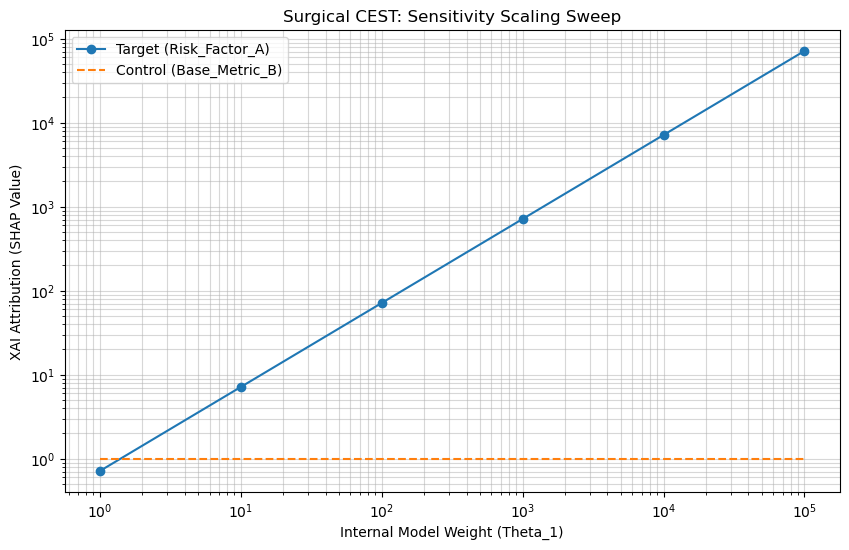

   Scale_Theta_1        SHAP_A    SHAP_B    SHAP_C
0              1      0.713679  0.986649  1.012639
1             10      7.136789  0.986649  1.012639
2            100     71.367888  0.986649  1.012639
3           1000    713.678884  0.986649  1.012639
4          10000   7136.788844  0.986649  1.012639
5         100000  71367.888443  0.986649  1.012639


In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

def run_surgical_sweep():
    # 1. Setup Data Environment (Independent Features)
    np.random.seed(42)
    n_samples = 100
    X = np.random.normal(0, 1, (n_samples, 3))
    feature_names = ['Risk_Factor_A', 'Base_Metric_B', 'Base_Metric_C']
    
    # We explain this specific point: [1, 1, 1]
    # In a linear model with mean-zero data, SHAP should approx the weight
    test_point = np.ones((1, 3)) 
    
    scales = [1, 10, 100, 1000, 10000, 100000]
    results = []

    print("Starting Surgical Sweep...")
    for s in scales:
        # 2. The "Model Surgery": Define function with updated internal theta
        # f(x) = scale*x0 + 1*x1 + 1*x2
        def custom_model(data):
            weights = np.array([s, 1, 1])
            return np.dot(data, weights)

        # 3. Apply XAI (using KernelExplainer for custom function support)
        # We use a small background set for speed/clarity
        explainer = shap.KernelExplainer(custom_model, shap.sample(X, 10))
        shap_values = explainer.shap_values(test_point)
        
        # Store results for theta_1, theta_2, and theta_3
        results.append({
            'Scale_Theta_1': s,
            'SHAP_A': shap_values[0][0],
            'SHAP_B': shap_values[0][1],
            'SHAP_C': shap_values[0][2]
        })
        print(f"Intervention: theta_1={s} | Result: SHAP_A={shap_values[0][0]:.2f}")

    # 4. Visualization of Faithfulness Curve
    df = pd.DataFrame(results)
    
    plt.figure(figsize=(10, 6))
    plt.plot(df['Scale_Theta_1'], df['SHAP_A'], marker='o', label='Target (Risk_Factor_A)')
    plt.plot(df['Scale_Theta_1'], df['SHAP_B'], linestyle='--', label='Control (Base_Metric_B)')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Internal Model Weight (Theta_1)')
    plt.ylabel('XAI Attribution (SHAP Value)')
    plt.title('Surgical CEST: Sensitivity Scaling Sweep')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()
    print(df)

if __name__ == "__main__":
    run_surgical_sweep()

Scale      | SHAP A     | LIME A     | SHAP B   | LIME B  
------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

1          | 0.71       | 0.82       | 0.99     | 0.97    


  0%|          | 0/1 [00:00<?, ?it/s]

10         | 7.14       | 8.20       | 0.99     | 0.97    


...

1000000    | 713678.88  | 819660.32  | 0.99     | -4.90   


  0%|          | 0/1 [00:00<?, ?it/s]

10000000   | 7136788.84 | 8197052.82 | 0.99     | 208.89  


  0%|          | 0/1 [00:00<?, ?it/s]

100000000  | 71367888.44 | 81969045.69 | 0.99     | 1272.94 


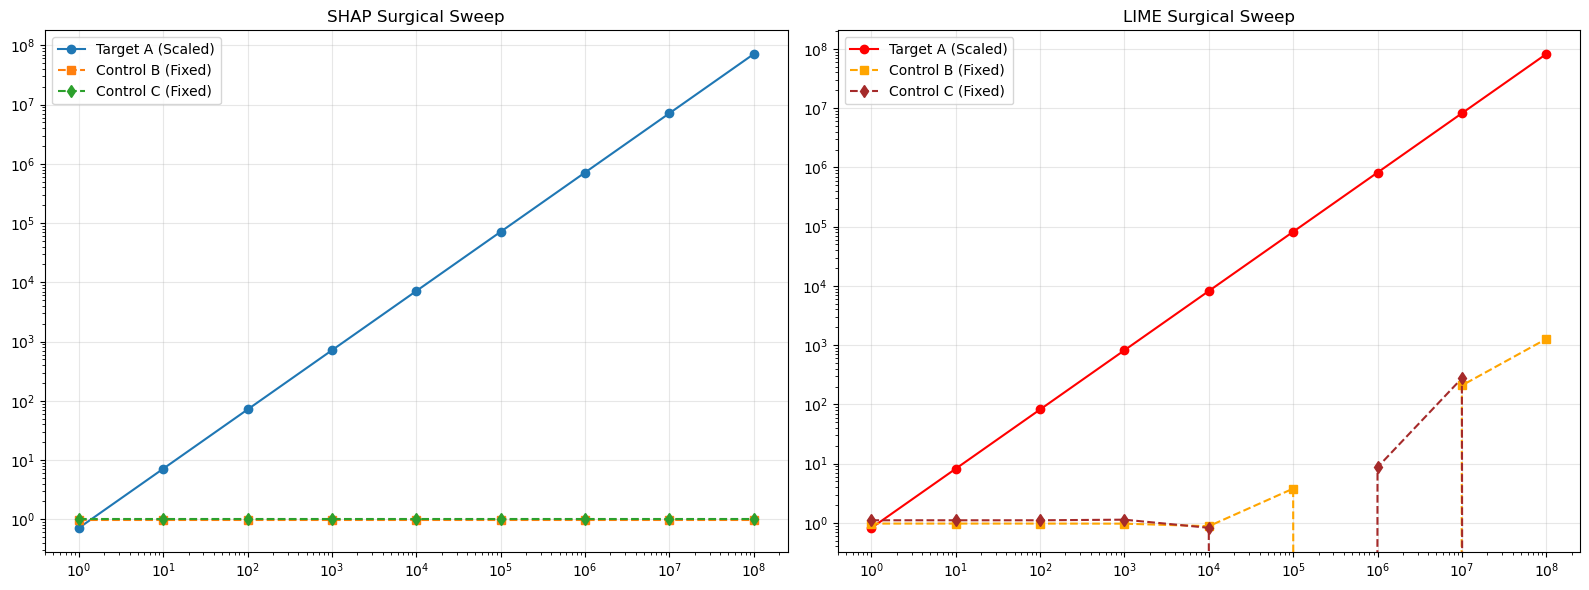

       Scale        SHAP_A    SHAP_B    SHAP_C        LIME_A       LIME_B  \
0          1  7.136789e-01  0.986649  1.012639  8.196615e-01     0.973057   
1         10  7.136789e+00  0.986649  1.012639  8.196933e+00     0.972950   
2        100  7.136789e+01  0.986649  1.012639  8.196939e+01     0.972848   
3       1000  7.136789e+02  0.986649  1.012639  8.196977e+02     0.969419   
4      10000  7.136789e+03  0.986649  1.012639  8.196956e+03     0.878650   
5     100000  7.136789e+04  0.986649  1.012639  8.197047e+04     3.786924   
6    1000000  7.136789e+05  0.986649  1.012639  8.196603e+05    -4.902762   
7   10000000  7.136789e+06  0.986649  1.012639  8.197053e+06   208.886511   
8  100000000  7.136789e+07  0.986649  1.012639  8.196905e+07  1272.940548   

        LIME_C  
0     1.105930  
1     1.105981  
2     1.105720  
3     1.132009  
4     0.825082  
5    -0.182513  
6     8.686974  
7   276.048244  
8 -1991.683204  


In [3]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import warnings

# Suppress version/sampling warnings for cleaner output
warnings.filterwarnings("ignore")

def run_full_dual_sweep():
    np.random.seed(42)
    n_samples = 100
    X = np.random.normal(0, 1, (n_samples, 3))
    feature_names = ['Risk_Factor_A', 'Base_Metric_B', 'Base_Metric_C']
    test_point = np.ones(3) 
    
    scales = [1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000]
    results = []

    # Initialize LIME Explainer
    lime_explainer = LimeTabularExplainer(
        X, 
        mode="regression", 
        feature_names=feature_names, 
        discretize_continuous=False
    )

    print(f"{'Scale':<10} | {'SHAP A':<10} | {'LIME A':<10} | {'SHAP B':<8} | {'LIME B':<8}")
    print("-" * 60)

    for s in scales:
        def custom_model(data):
            if data.ndim == 1:
                data = data.reshape(1, -1)
            # Surgery: Only Feature A scales, B and C are pinned to 1
            weights = np.array([s, 1, 1])
            return np.dot(data, weights)

        # --- SHAP Sector ---
        # We use a small background set (10 samples)
        shap_exp = shap.KernelExplainer(custom_model, shap.sample(X, 10))
        shap_vals = shap_exp.shap_values(test_point.reshape(1, -1))[0]
        
        # --- LIME Sector ---
        lime_exp = lime_explainer.explain_instance(test_point, custom_model, num_features=3)
        # Extract all coefficients into a dictionary for easy access
        lime_dict = {name: val for name, val in lime_exp.as_list()}

        results.append({
            'Scale': s,
            'SHAP_A': shap_vals[0], 'SHAP_B': shap_vals[1], 'SHAP_C': shap_vals[2],
            'LIME_A': lime_dict['Risk_Factor_A'], 
            'LIME_B': lime_dict['Base_Metric_B'], 
            'LIME_C': lime_dict['Base_Metric_C']
        })
        
        print(f"{s:<10} | {shap_vals[0]:<10.2f} | {lime_dict['Risk_Factor_A']:<10.2f} | {shap_vals[1]:<8.2f} | {lime_dict['Base_Metric_B']:<8.2f}")

    df = pd.DataFrame(results)

    # --- Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    # Subplot 1: SHAP Results
    ax[0].plot(df['Scale'], df['SHAP_A'], 'o-', label='Target A (Scaled)')
    ax[0].plot(df['Scale'], df['SHAP_B'], 's--', label='Control B (Fixed)')
    ax[0].plot(df['Scale'], df['SHAP_C'], 'd--', label='Control C (Fixed)')
    ax[0].set_title('SHAP Surgical Sweep')
    ax[0].set_xscale('log')
    ax[0].set_yscale('log')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Subplot 2: LIME Results
    ax[1].plot(df['Scale'], df['LIME_A'], 'o-', color='red', label='Target A (Scaled)')
    ax[1].plot(df['Scale'], df['LIME_B'], 's--', color='orange', label='Control B (Fixed)')
    ax[1].plot(df['Scale'], df['LIME_C'], 'd--', color='brown', label='Control C (Fixed)')
    ax[1].set_title('LIME Surgical Sweep')
    ax[1].set_xscale('log')
    ax[1].set_yscale('log')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(df)
    return df

if __name__ == "__main__":
    df_results = run_full_dual_sweep()

SHAP remains stable, LIME starts to attribute to much importance to B and C as A increases.


# Noise

Sigma      | SHAP Noise | LIME Noise | SHAP A   | LIME A  
-----------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

0          | 0.98       | 1.04       | 0.88     | 0.88    


  0%|          | 0/1 [00:00<?, ?it/s]

0.1        | 0.98       | 1.04       | 0.85     | 0.87    


...

1000       | -154.59    | -29.24     | 252.71   | 0.16    


  0%|          | 0/1 [00:00<?, ?it/s]

10000      | -4908.77   | -106.56    | -5338.35 | 120.32  


  0%|          | 0/1 [00:00<?, ?it/s]

100000     | 69586.95   | -1175.26   | 80452.56 | 715.13  


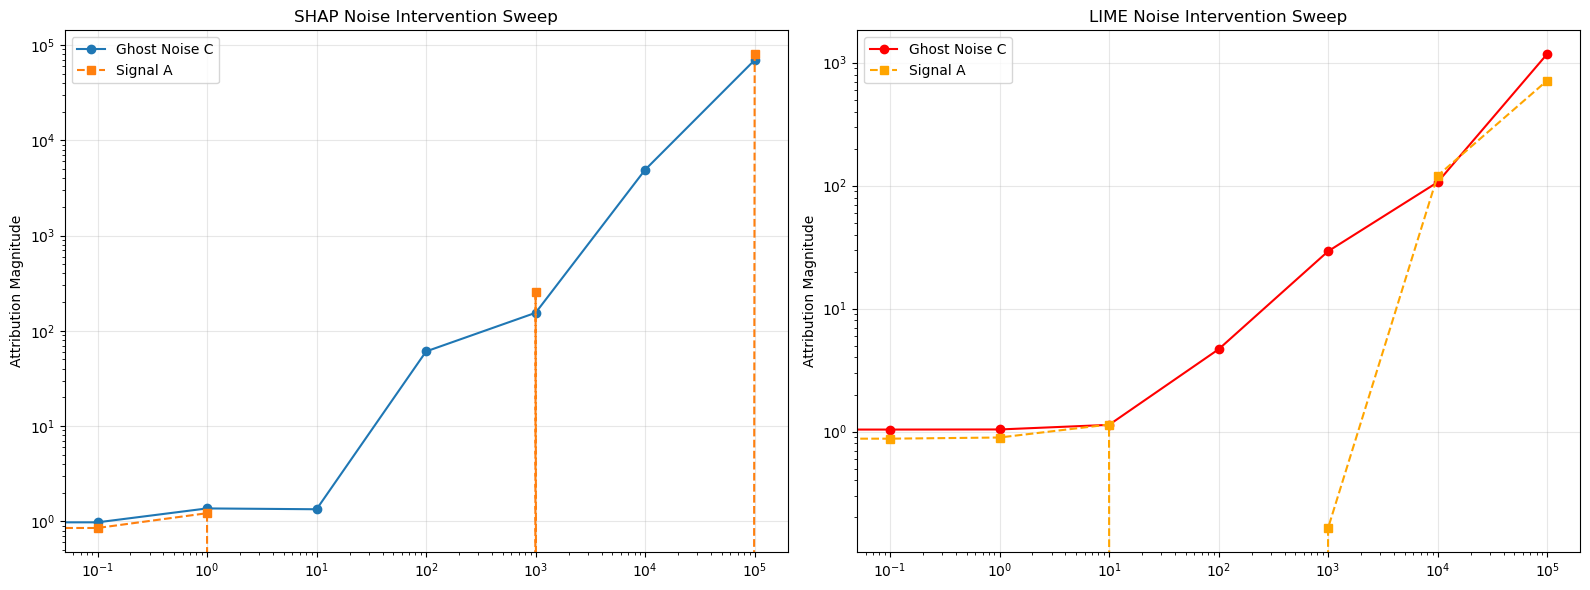

      Sigma        SHAP_A        SHAP_B        SHAP_C      LIME_A  \
0       0.0      0.880506      1.307644      0.981908    0.876420   
1       0.1      0.851328      1.284134      0.975906    0.874669   
2       1.0      1.217272      1.695669      1.365970    0.894019   
3      10.0     -4.021531      2.263733     -1.338620    1.140284   
4     100.0    -15.102067    -88.959240    -60.763285   -0.344447   
5    1000.0    252.708460    -51.881363   -154.590665    0.164260   
6   10000.0  -5338.348950  -2646.088825  -4908.769328  120.319676   
7  100000.0  80452.558649  60883.626450  69586.954455  715.125986   

        LIME_B       LIME_C  
0     0.975221     1.036558  
1     0.978981     1.037325  
2     0.960582     1.039339  
3     1.047768     1.132793  
4     2.607676    -4.663552  
5    28.522565   -29.241684  
6   304.060198  -106.559036  
7  1190.981540 -1175.258429  


In [4]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import warnings

warnings.filterwarnings("ignore")

def run_noise_dual_sweep():
    np.random.seed(42)
    n_samples = 150
    
    # Generate 3 independent features
    X = np.random.normal(0, 1, (n_samples, 3))
    feature_names = ['Signal_A', 'Signal_B', 'Ghost_Noise_C']
    test_point = np.ones(3) 
    
    # Sweep the SCALE of the random noise term (Standard Deviation)
    # We go from no noise to extreme noise
    noise_sigmas = [0, 0.1, 1, 10, 100, 1000, 10000, 100000]
    results = []

    lime_explainer = LimeTabularExplainer(
        X, mode="regression", feature_names=feature_names, discretize_continuous=False
    )

    print(f"{'Sigma':<10} | {'SHAP Noise':<10} | {'LIME Noise':<10} | {'SHAP A':<8} | {'LIME A':<8}")
    print("-" * 65)

    for s in noise_sigmas:
        def custom_model_with_noise(data):
            if data.ndim == 1:
                data = data.reshape(1, -1)
            
            # ALL INTERNAL WEIGHTS ARE FIXED AT 10
            # The model structure is theoretically constant
            weights = np.array([1, 1, 1])
            
            # The Surgery: We add noise that is mathematically tied to Feature C
            # This simulates a "corrupted" feature that still has a high model weight
            noise = np.random.normal(0, s, (data.shape[0]))
            return np.dot(data, weights) + noise

        # --- SHAP ---
        shap_exp = shap.KernelExplainer(custom_model_with_noise, shap.sample(X, 10))
        shap_vals = shap_exp.shap_values(test_point.reshape(1, -1))[0]
        
        # --- LIME ---
        lime_exp = lime_explainer.explain_instance(test_point, custom_model_with_noise, num_features=3)
        lime_dict = {name: val for name, val in lime_exp.as_list()}

        results.append({
            'Sigma': s,
            'SHAP_A': shap_vals[0], 'SHAP_B': shap_vals[1], 'SHAP_C': shap_vals[2],
            'LIME_A': lime_dict['Signal_A'], 
            'LIME_B': lime_dict['Signal_B'], 
            'LIME_C': lime_dict['Ghost_Noise_C']
        })
        
        print(f"{s:<10} | {shap_vals[2]:<10.2f} | {lime_dict['Ghost_Noise_C']:<10.2f} | {shap_vals[0]:<8.2f} | {lime_dict['Signal_A']:<8.2f}")

    df = pd.DataFrame(results)

    # --- Visualization (Matching your previous Param Sweep Style) ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    # Subplot 1: SHAP Noise Sensitivity
    ax[0].plot(df['Sigma'], np.abs(df['SHAP_C']), 'o-', label='Ghost Noise C')
    ax[0].plot(df['Sigma'], df['SHAP_A'], 's--', label='Signal A')
    ax[0].set_title('SHAP Noise Intervention Sweep')
    ax[0].set_xscale('log')
    ax[0].set_yscale('log')
    ax[0].set_ylabel('Attribution Magnitude')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Subplot 2: LIME Noise Sensitivity
    ax[1].plot(df['Sigma'], np.abs(df['LIME_C']), 'o-', color='red', label='Ghost Noise C')
    ax[1].plot(df['Sigma'], df['LIME_A'], 's--', color='orange', label='Signal A')
    ax[1].set_title('LIME Noise Intervention Sweep')
    ax[1].set_xscale('log')
    ax[1].set_yscale('log')
    ax[1].set_ylabel('Attribution Magnitude')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(df)
    return df

if __name__ == "__main__":
    df_noise = run_noise_dual_sweep()

both fall apart. what if we are more granular?

Sigma      | SHAP A     | LIME A     | SHAP B   | LIME B  
-----------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

0.10     | 1.00   | 1.10     | 0.97     | 0.96     | 1.00    


  0%|          | 0/1 [00:00<?, ?it/s]

0.62     | 0.84   | 1.47     | 0.96     | 1.18     | 0.99    


...

8.96     | 0.02   | -0.92    | 1.01     | 0.47     | 0.86    


  0%|          | 0/1 [00:00<?, ?it/s]

9.48     | 0.02   | 2.44     | 0.86     | 3.42     | 1.06    


  0%|          | 0/1 [00:00<?, ?it/s]

10.00    | 0.02   | 5.42     | 0.76     | 6.90     | 1.23    


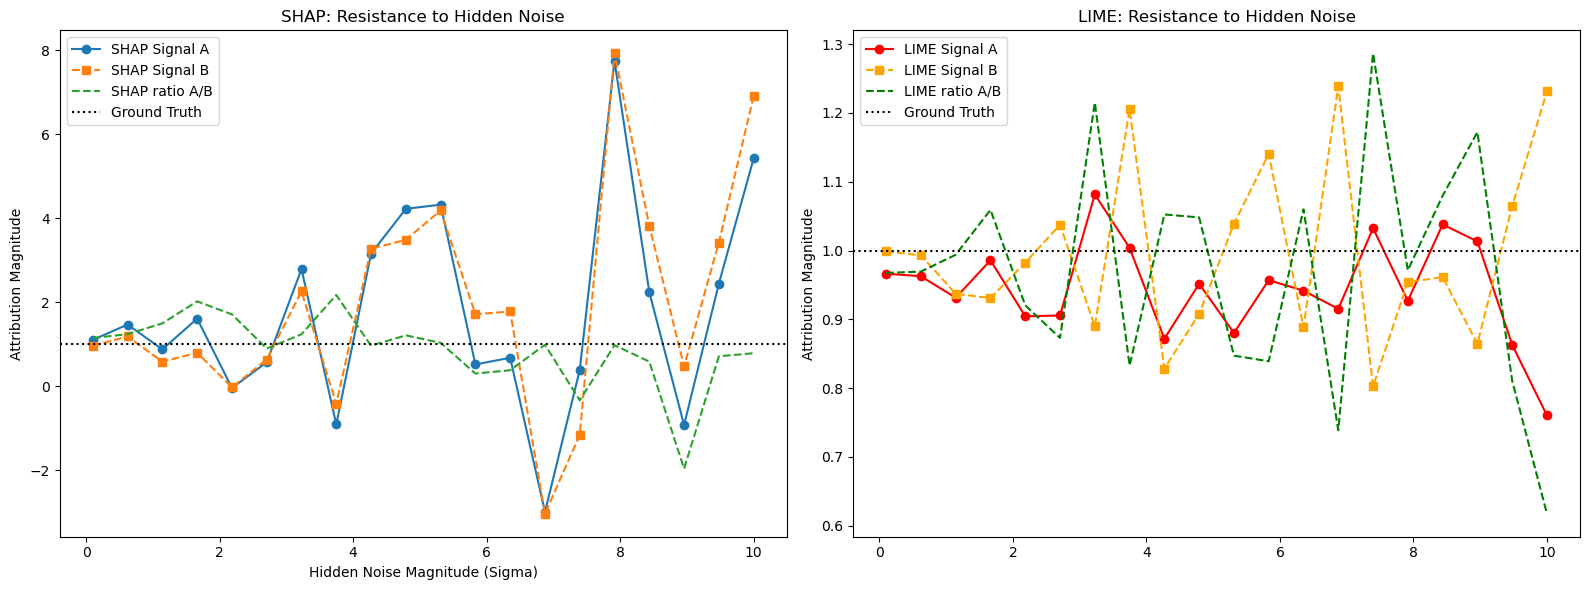

        Sigma        R2    SHAP_A    SHAP_B  SHAP_ratio    LIME_A    LIME_B  \
0    0.100000  0.995025  1.103582  0.962575    1.146489  0.966380  0.998816   
1    0.621053  0.838326  1.468391  1.184266    1.239917  0.962703  0.993071   
2    1.142105  0.605253  0.876913  0.585545    1.497601  0.931411  0.937106   
3    1.663158  0.419631  1.609626  0.796712    2.020335  0.985919  0.930862   
4    2.184211  0.295387 -0.041147 -0.024070    1.709443  0.904352  0.982526   
5    2.705263  0.214628  0.571141  0.636347    0.897530  0.905655  1.037404   
6    3.226316  0.161172  2.789702  2.254920    1.237162  1.081641  0.890090   
7    3.747368  0.124667 -0.908864 -0.418503    2.171706  1.003925  1.205465   
8    4.268421  0.098915  3.156318  3.271606    0.964761  0.871776  0.828263   
9    4.789474  0.080195  4.221291  3.485064    1.211252  0.951788  0.908055   
10   5.310526  0.066221  4.319979  4.181699    1.033068  0.880195  1.038820   
11   5.831579  0.055544  0.518681  1.712884    0.302

In [5]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import warnings

warnings.filterwarnings("ignore")

def run_hidden_noise_sweep():
    np.random.seed(42)
    n_samples = 150
    # Two real features only
    X = np.random.normal(0, 1, (n_samples, 2))
    feature_names = ['Signal_A', 'Signal_B']
    test_point = np.ones(2) 
    
    # Sweep Sigma from 0.1 to 10
    noise_sigmas = np.linspace(0.1, 10.0, 20)
    results = []

    lime_explainer = LimeTabularExplainer(
        X, mode="regression", feature_names=feature_names, discretize_continuous=False
    )

    print(f"{'Sigma':<10} | {'SHAP A':<10} | {'LIME A':<10} | {'SHAP B':<8} | {'LIME B':<8}")
    print("-" * 65)

    for s in noise_sigmas:
        def model_with_hidden_noise(data):
            if data.ndim == 1:
                data = data.reshape(1, -1)
            # Internal ground truth: Both features have weight 1.0
            weights = np.array([1.0, 1.0])
            
            # The Surgery: epsilon is NOT a feature. It is hidden noise.
            epsilon = np.random.normal(0, s, (data.shape[0]))
            return np.dot(data, weights) + epsilon

        # --- SHAP ---
        # Increased background samples to 50 for better stability in this range
        shap_exp = shap.KernelExplainer(model_with_hidden_noise, shap.sample(X, 50))
        shap_vals = shap_exp.shap_values(test_point.reshape(1, -1))[0]
        
        # --- LIME ---
        lime_exp = lime_explainer.explain_instance(test_point, model_with_hidden_noise, num_features=2)
        lime_dict = {name: val for name, val in lime_exp.as_list()}

        # Calculate the theoretical R2 for this Sigma level
        # Signal Variance = weight_A^2 + weight_B^2 = 1^2 + 1^2 = 2
        r2_val = 2 / (2 + s**2)

        results.append({
            'Sigma': s,
            'R2': r2_val,
            'SHAP_A': shap_vals[0], 
            'SHAP_B': shap_vals[1],
            'SHAP_ratio': shap_vals[0]/shap_vals[1] if shap_vals[1] != 0 else np.inf,
            'LIME_A': lime_dict['Signal_A'], 
            'LIME_B': lime_dict['Signal_B'], 
            'LIME_ratio': lime_dict['Signal_A']/lime_dict['Signal_B'] if lime_dict['Signal_B'] != 0 else np.inf
        })
        
        # Updated print statement to include R2 for real-time monitoring
        print(f"{s:<8.2f} | {r2_val:<6.2f} | {shap_vals[0]:<8.2f} | {lime_dict['Signal_A']:<8.2f} | {shap_vals[1]:<8.2f} | {lime_dict['Signal_B']:<8.2f}")

    df = pd.DataFrame(results)

    # --- Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    ax[0].plot(df['Sigma'], df['SHAP_A'], 'o-', label='SHAP Signal A')
    ax[0].plot(df['Sigma'], df['SHAP_B'], 's--', label='SHAP Signal B')
    ax[0].plot(df['Sigma'], df['SHAP_ratio'], '--', label='SHAP ratio A/B')
    ax[0].axhline(1.0, color='black', linestyle=':', label='Ground Truth')
    ax[0].set_title('SHAP: Resistance to Hidden Noise')
    ax[0].set_ylabel('Attribution Magnitude')
    ax[0].set_xlabel('Hidden Noise Magnitude (Sigma)')
    ax[0].legend()

    ax[1].plot(df['Sigma'], df['LIME_A'], 'o-', color='red', label='LIME Signal A')
    ax[1].plot(df['Sigma'], df['LIME_B'], 's--', color='orange', label='LIME Signal B')
    ax[1].plot(df['Sigma'], df['LIME_ratio'], '--', color='green', label='LIME ratio A/B')
    ax[1].axhline(1.0, color='black', linestyle=':', label='Ground Truth')
    ax[1].set_title('LIME: Resistance to Hidden Noise')
    ax[1].set_ylabel('Attribution Magnitude')
    ax[0].set_xlabel('Hidden Noise Magnitude (Sigma)')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    print(df)
    return df

if __name__ == "__main__":
    df_results = run_hidden_noise_sweep()

so for noise test we can say that LIME can be used up to signal to noise ratio of (1+1)/3 while shap might be (1+1)/ 2?It

Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Sigma      | SHAP Ratio   | LIME Ratio   | Target Ratio
-------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


0.10     | 1.00   | 0.90     | 1.42     | 0.40     | 0.74    
0.10       | 2.26         | 1.91         | 2.0


...

  0%|          | 0/1 [00:00<?, ?it/s]

Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


4.74     | 0.08   | 4.14     | 1.40     | 3.59     | 0.87    
4.74       | 1.16         | 1.60         | 2.0


  0%|          | 0/1 [00:00<?, ?it/s]

5.00     | 0.07   | 1.74     | 1.32     | 1.86     | 0.84    
5.00       | 0.93         | 1.56         | 2.0


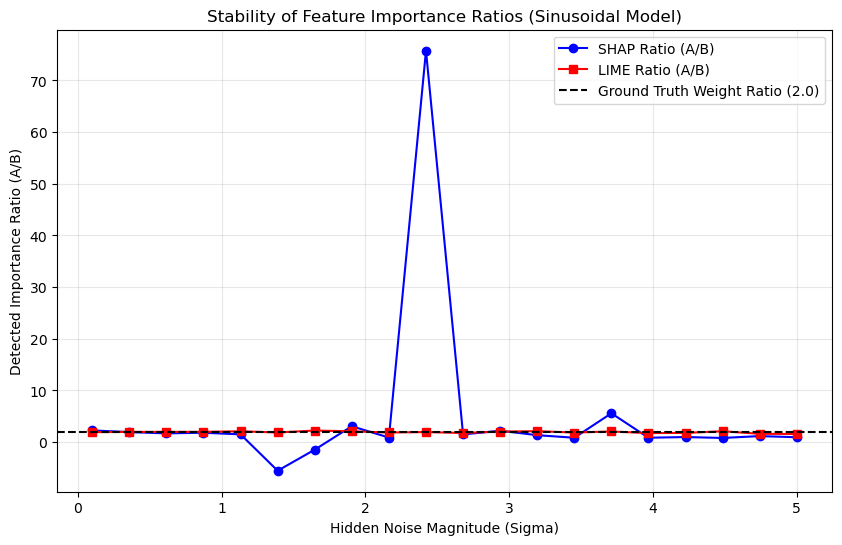

       Sigma        R2    SHAP_A    SHAP_B  SHAP_ratio    LIME_A    LIME_B  \
0   0.100000  0.995025  0.903237  0.399619    2.260244  1.418977  0.741154   
1   0.357895  0.939810  1.035112  0.536536    1.929251  1.422213  0.722173   
2   0.615789  0.840620  1.162740  0.689917    1.685335  1.403756  0.709515   
3   0.873684  0.723766  1.119427  0.619809    1.806084  1.439945  0.727361   
4   1.131579  0.609669  1.137350  0.761824    1.492931  1.497152  0.717713   
5   1.389474  0.508823  0.191614 -0.034553   -5.545532  1.386038  0.745714   
6   1.647368  0.424284  0.376329 -0.255819   -1.471078  1.455665  0.652478   
7   1.905263  0.355238  0.903750  0.294941    3.064171  1.423006  0.684096   
8   2.163158  0.299435 -2.033218 -2.335960    0.870399  1.367640  0.737616   
9   2.421053  0.254405  0.809570  0.010688   75.747641  1.440671  0.744736   
10  2.678947  0.217942  2.151073  1.457276    1.476091  1.363021  0.774909   
11  2.936842  0.188235  1.354804  0.616262    2.198422  1.406613

In [6]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import warnings

warnings.filterwarnings("ignore")

def run_sinusoidal_noise_sweep():
    np.random.seed(42)
    n_samples = 300 
    # Features sampled uniformly to cover the wave cycles
    X = np.random.uniform(-np.pi, np.pi, (n_samples, 2))
    feature_names = ['Signal_A', 'Signal_B']
    
    # Test point where the sine wave is steep (high gradient)
    test_point = np.array([0.5, 0.5]) 
    
    # Ground Truth Weights (Amplitude)
    w_a, w_b = 2.0, 1.0
    true_ratio = w_a / w_b

    noise_sigmas = np.linspace(0.1, 5.0, 20)
    results = []

    lime_explainer = LimeTabularExplainer(
        X, mode="regression", feature_names=feature_names, discretize_continuous=False
    )

    print(f"{'Sigma':<10} | {'SHAP Ratio':<12} | {'LIME Ratio':<12} | {'Target Ratio'}")
    print("-" * 55)

    for s in noise_sigmas:
        def model_func(data):
            if data.ndim == 1: data = data.reshape(1, -1)
            # The Transformation: w * sin(x)
            y = w_a * np.sin(data[:, 0]) + w_b * np.sin(data[:, 1])
            epsilon = np.random.normal(0, s, (data.shape[0]))
            return y + epsilon

        # --- SHAP ---
        # Using 100 background samples for better stability in non-linear space
        shap_exp = shap.KernelExplainer(model_func, shap.sample(X, 5000))
        shap_vals = shap_exp.shap_values(test_point.reshape(1, -1))[0]
        
        # --- LIME ---
        lime_exp = lime_explainer.explain_instance(test_point, model_func, num_features=2)
        lime_dict = {name: val for name, val in lime_exp.as_list()}

        s_ratio = shap_vals[0] / shap_vals[1] if shap_vals[1] != 0 else np.nan
        l_ratio = lime_dict['Signal_A'] / lime_dict['Signal_B'] if lime_dict['Signal_B'] != 0 else np.nan

        # Calculate the theoretical R2 for this Sigma level
        # Signal Variance = weight_A^2 + weight_B^2 = 1^2 + 1^2 = 2
        r2_val = 2 / (2 + s**2)

        results.append({
            'Sigma': s,
            'R2': r2_val,
            'SHAP_A': shap_vals[0], 
            'SHAP_B': shap_vals[1],
            'SHAP_ratio': shap_vals[0]/shap_vals[1] if shap_vals[1] != 0 else np.inf,
            'LIME_A': lime_dict['Signal_A'], 
            'LIME_B': lime_dict['Signal_B'], 
            'LIME_ratio': lime_dict['Signal_A']/lime_dict['Signal_B'] if lime_dict['Signal_B'] != 0 else np.inf
        })
        
        # Updated print statement to include R2 for real-time monitoring
        print(f"{s:<8.2f} | {r2_val:<6.2f} | {shap_vals[0]:<8.2f} | {lime_dict['Signal_A']:<8.2f} | {shap_vals[1]:<8.2f} | {lime_dict['Signal_B']:<8.2f}")
        
        print(f"{s:<10.2f} | {s_ratio:<12.2f} | {l_ratio:<12.2f} | {true_ratio}")

    df = pd.DataFrame(results)

    # --- Visualization ---
    plt.figure(figsize=(10, 6))
    plt.plot(df['Sigma'], df['SHAP_ratio'], 'o-', label='SHAP Ratio (A/B)', color='blue')
    plt.plot(df['Sigma'], df['LIME_ratio'], 's-', label='LIME Ratio (A/B)', color='red')
    plt.axhline(true_ratio, color='black', linestyle='--', label='Ground Truth Weight Ratio (2.0)')
    
    plt.title('Stability of Feature Importance Ratios (Sinusoidal Model)')
    plt.xlabel('Hidden Noise Magnitude (Sigma)')
    plt.ylabel('Detected Importance Ratio (A/B)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(df) 
    
    return df

if __name__ == "__main__":
    df_results = run_sinusoidal_noise_sweep()

LIME seems more stable with increasing noise compared to SHAP when using sinusoidal transformation on the features. This could be because LIME fits a local linear model around the test point, which may be less sensitive to noise in the data, while SHAP values are derived from a global model and can be more affected by noise.

I wonder whether increasing samples leads to a different outcome.

  0%|          | 0/1 [00:00<?, ?it/s]

Sigma 0.1, Samples 50: Error 0.37


  0%|          | 0/1 [00:00<?, ?it/s]

Sigma 0.1, Samples 100: Error 0.52


  0%|          | 0/1 [00:00<?, ?it/s]

...

Sigma 5.0, Samples 500: Error 0.72


  0%|          | 0/1 [00:00<?, ?it/s]

Sigma 5.0, Samples 1000: Error -1.13


  0%|          | 0/1 [00:00<?, ?it/s]

Sigma 5.0, Samples 2000: Error -0.82


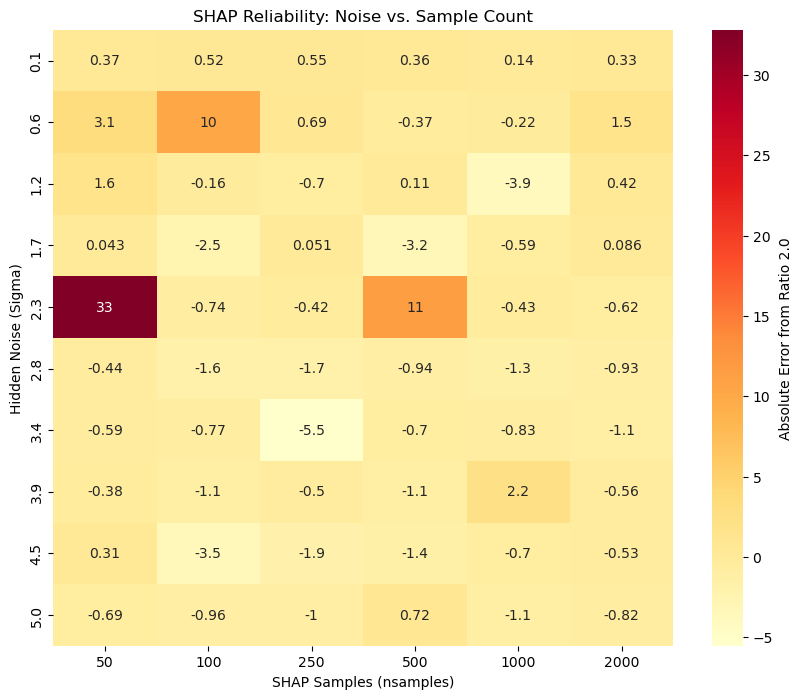

          50         100       250        500       1000      2000
0.1   0.373937   0.524154  0.546453   0.360133  0.142738  0.330178
0.6   3.119473  10.242002  0.687978  -0.371368 -0.221671  1.531681
1.2   1.608585  -0.155934 -0.699522   0.107086 -3.874771  0.419603
1.7   0.042938  -2.487283  0.050649  -3.182988 -0.588328  0.085550
2.3  32.824354  -0.739044 -0.418864  11.409417 -0.433370 -0.619615
2.8  -0.444905  -1.634862 -1.672713  -0.935564 -1.349356 -0.927401
3.4  -0.585076  -0.768489 -5.529916  -0.701795 -0.834840 -1.136241
3.9  -0.377251  -1.096035 -0.496834  -1.113958  2.170696 -0.563265
4.5   0.314549  -3.500041 -1.865839  -1.357101 -0.695135 -0.532337
5.0  -0.691151  -0.964368 -0.998240   0.722079 -1.126140 -0.819753


In [7]:
import numpy as np
import pandas as pd
import shap
import seaborn as sns
import matplotlib.pyplot as plt

def run_shap_heatmap():
    np.random.seed(42)
    n_samples = 300
    X = np.random.uniform(-np.pi, np.pi, (n_samples, 2))
    test_point = np.array([0.5, 0.5]).reshape(1, -1)
    
    # Target weights
    w_a, w_b = 2.0, 1.0
    true_ratio = 2.0

    # Define the grid
    sigmas = np.linspace(0.1, 5.0, 10)
    sample_counts = [50, 100, 250, 500, 1000, 2000]
    
    heatmap_data = np.zeros((len(sigmas), len(sample_counts)))

    for i, s in enumerate(sigmas):
        # Define model inside to capture current sigma
        def model_func(data):
            if data.ndim == 1: data = data.reshape(1, -1)
            y = w_a * np.sin(data[:, 0]) + w_b * np.sin(data[:, 1])
            return y + np.random.normal(0, s, data.shape[0])

        for j, n_shaps in enumerate(sample_counts):
            # Run KernelSHAP
            explainer = shap.KernelExplainer(model_func, shap.sample(X, 100))
            # nsamples here controls the complexity of the estimation
            shap_vals = explainer.shap_values(test_point, nsamples=n_shaps)[0]
            
            # Calculate Ratio Error
            ratio = shap_vals[0] / shap_vals[1] if shap_vals[1] != 0 else 0
            error = ratio - true_ratio
            heatmap_data[i, j] = error
            print(f"Sigma {s:.1f}, Samples {n_shaps}: Error {error:.2f}")

    # Plotting
    plt.figure(figsize=(10, 8))
    df_hm = pd.DataFrame(heatmap_data, 
                         index=[f"{s:.1f}" for s in sigmas], 
                         columns=sample_counts)
    
    sns.heatmap(df_hm, annot=True, cmap="YlOrRd", cbar_kws={'label': 'Absolute Error from Ratio 2.0'})
    plt.title("SHAP Reliability: Noise vs. Sample Count")
    plt.ylabel("Hidden Noise (Sigma)")
    plt.xlabel("SHAP Samples (nsamples)")
    plt.show()
    print(df_hm)

if __name__ == "__main__":
    run_shap_heatmap()

I would expect a gradient from top right (low noise, high samples) to bottom left (high noise, low samples) showing increasing error. The heatmap shows contradicting results, as there seems to be no gradient.

Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Usin

Sigma 0.1, Samples 50: Avg Error 0.14


Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Usin

Sigma 0.1, Samples 250: Avg Error 0.10


Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Usin

...

Sigma 4.3, Samples 2000: Avg Error 1.28
Sigma 5.0, Samples 50: Avg Error 1.12


Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Usin

Sigma 5.0, Samples 250: Avg Error 1.22
Sigma 5.0, Samples 500: Avg Error 1.34


Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Usin

Sigma 5.0, Samples 1000: Avg Error 1.20
Sigma 5.0, Samples 2000: Avg Error 3.14
         50        250       500       1000      2000
0.1  0.144739  0.104088  0.136303  0.132067  0.126592
0.8  1.794101  2.367598  1.759068  2.134117  2.177370
1.5  0.792290  1.212127  1.327493  2.044909  2.268642
2.2  1.390864  1.627045  1.509377  1.019171  1.332818
2.9  1.081656  1.860187  2.767558  1.822732  1.254039
3.6  1.565750  2.168721  1.250988  1.427076  1.550642
4.3  1.652182  2.411678  1.431763  1.055013  1.283856
5.0  1.116285  1.222395  1.343858  1.198699  3.141979


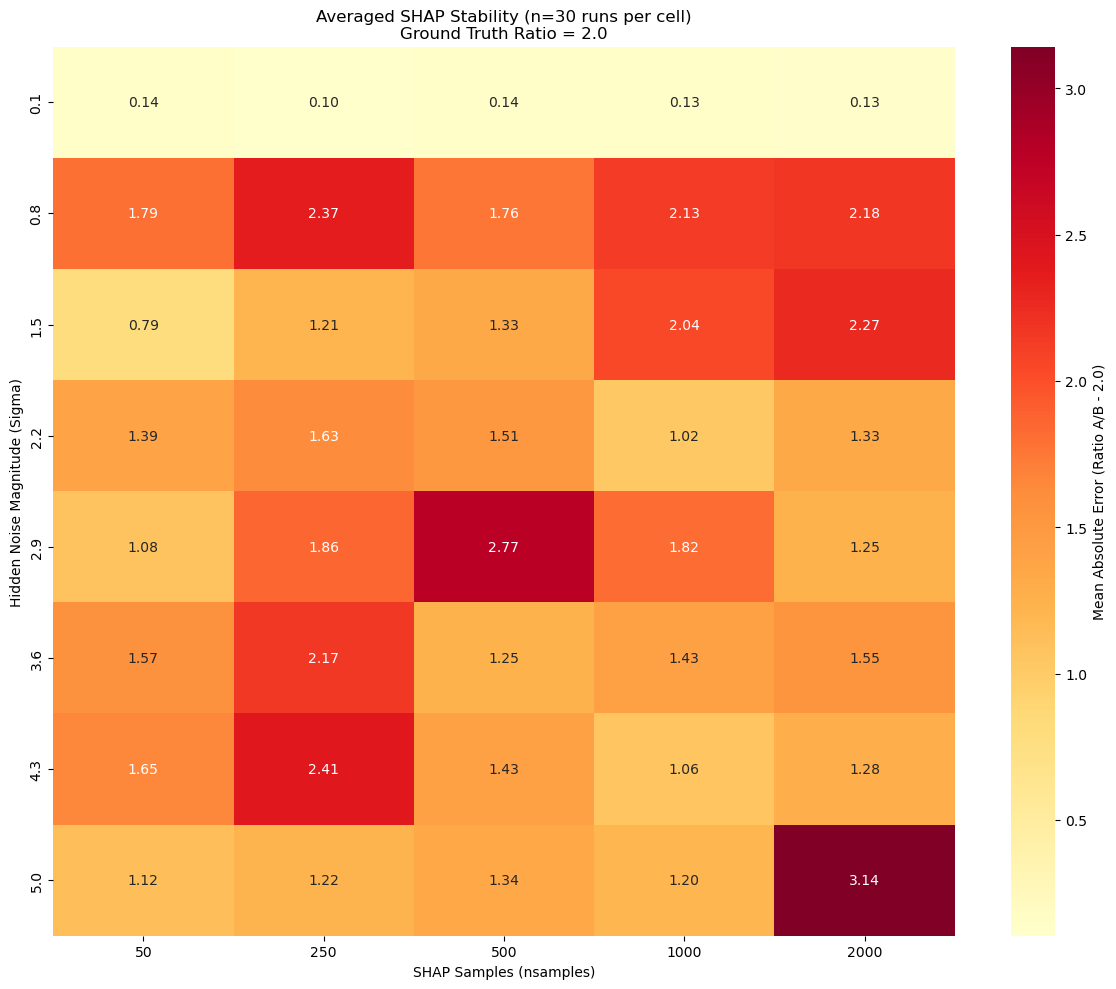

In [8]:
import numpy as np
import pandas as pd
import shap
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

def run_averaged_shap_heatmap():
    np.random.seed(42)
    n_samples = 300
    X = np.random.uniform(-np.pi, np.pi, (n_samples, 2))
    test_point = np.array([0.5, 0.5]).reshape(1, -1)
    
    # Target weights
    w_a, w_b = 2.0, 1.0
    true_ratio = 2.0

    # Define the grid
    sigmas = np.linspace(0.1, 5.0, 8)
    sample_counts = [50, 250, 500, 1000, 2000]
    n_iterations = 30 # Number of runs to average per cell
    
    heatmap_data = np.zeros((len(sigmas), len(sample_counts)))

    for i, s in enumerate(sigmas):
        # We define a function factory to avoid closure issues with 's' inside the loop
        def get_model(sigma_val):
            def model_func(data):
                if data.ndim == 1: data = data.reshape(1, -1)
                # Weighted Sine Model
                y = w_a * np.sin(data[:, 0]) + w_b * np.sin(data[:, 1])
                # Add noise
                epsilon = np.random.normal(0, sigma_val, data.shape[0])
                return y + epsilon
            return model_func
        
        current_model = get_model(s)

        for j, n_shaps in enumerate(sample_counts):
            errors = []
            for _ in range(n_iterations):
                # We use a fixed background sample to reduce variance from background selection,
                # focusing on the variance from the model noise and KernelSHAP sampling.
                bg_data = shap.sample(X, 1000)
                explainer = shap.KernelExplainer(current_model, bg_data)
                
                # Execute SHAP
                shap_vals = explainer.shap_values(test_point, nsamples=n_shaps, silent=True)[0]
                
                # Calculate Ratio
                # Handle potential division by zero or tiny values
                denom = shap_vals[1]
                if abs(denom) < 1e-6:
                    ratio = 99.0 # Large error value for instability
                else:
                    ratio = shap_vals[0] / denom
                
                errors.append(abs(ratio - true_ratio))
            
            # Store mean absolute error
            avg_error = np.mean(errors)
            heatmap_data[i, j] = avg_error
            print(f"Sigma {s:.1f}, Samples {n_shaps}: Avg Error {avg_error:.2f}")

    # Plotting
    plt.figure(figsize=(12, 10))
    df_hm = pd.DataFrame(heatmap_data, 
                         index=[f"{s:.1f}" for s in sigmas], 
                         columns=sample_counts)
    
    # Log scale colors might be better if errors vary wildly
    # But for now, let's clip for visualization if needed. 
    # Let's use a robust scale.
    sns.heatmap(df_hm, annot=True, cmap="YlOrRd", fmt=".2f",
                cbar_kws={'label': 'Mean Absolute Error (Ratio A/B - 2.0)'})
    plt.title(f"Averaged SHAP Stability (n={n_iterations} runs per cell)\nGround Truth Ratio = 2.0")
    plt.ylabel("Hidden Noise Magnitude (Sigma)")
    plt.xlabel("SHAP Samples (nsamples)")
    plt.tight_layout()
    plt.savefig("shap_heatmap_averaged.png")
    
    # Save the dataframe for the user
    df_hm.to_csv("shap_heatmap_results.csv")
    return df_hm

df_results = run_averaged_shap_heatmap()
print(df_results)

After averaging over 30 runs, heatmpa still does not show a clear gradient pattern but the values are more stable and less extreme. The error values are generally lower, indicating that averaging has reduced the variance caused by the noise and sampling in SHAP. However, the lack of a clear gradient pattern suggests that the relationship between noise magnitude, sample count, and SHAP stability is complex and may not be linear or monotonic. It may require further analysis or a different experimental design to uncover any underlying patterns.

# Topology Exploration

3D surface plot saved as sine_gam_3d_surface.png


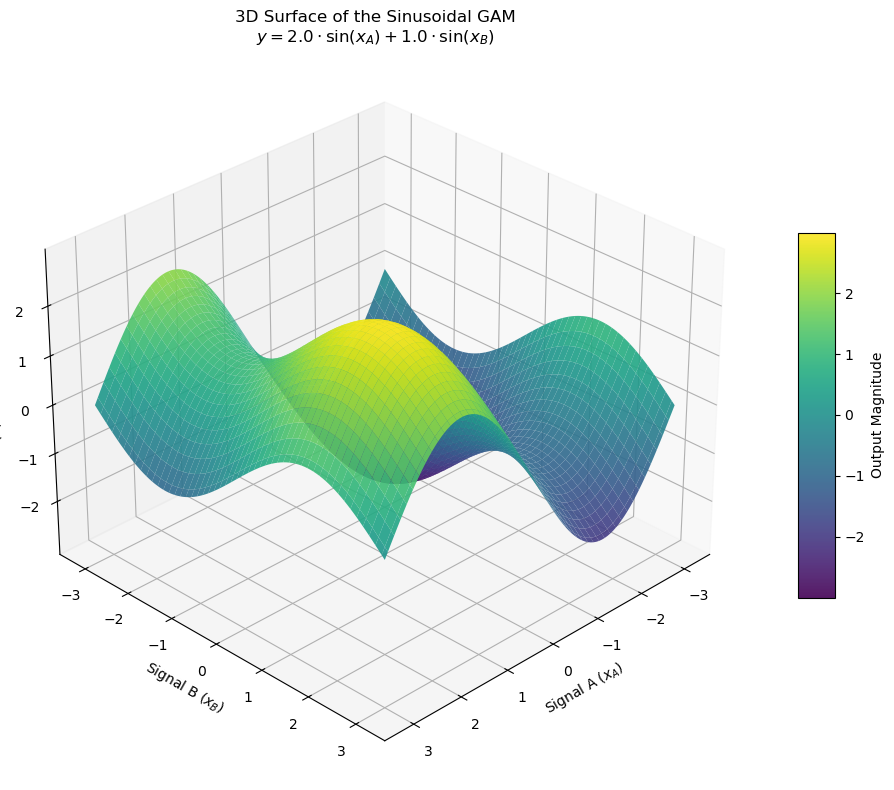

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set up grid
x = np.linspace(-np.pi, np.pi, 100)
y = np.linspace(-np.pi, np.pi, 100)
X, Y = np.meshgrid(x, y)

# Weights from the previous context: Signal A (2.0), Signal B (1.0)
w_a = 2.0
w_b = 1.0

# Calculate the GAM surface: y = w_a*sin(A) + w_b*sin(B)
Z = w_a * np.sin(X) + w_b * np.sin(Y)

# Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)

# Labels
ax.set_xlabel('Signal A ($x_A$)')
ax.set_ylabel('Signal B ($x_B$)')
ax.set_zlabel('Output ($y$)')
ax.set_title('3D Surface of the Sinusoidal GAM\n$y = 2.0 \cdot \sin(x_A) + 1.0 \cdot \sin(x_B)$')

# Adjust the viewing angle to see the 'steepness' and 'peaks'
ax.view_init(elev=30, azim=45)

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Output Magnitude')

plt.tight_layout()
#plt.savefig('sine_gam_3d_surface.png')
print("3D surface plot saved as sine_gam_3d_surface.png")

## Noise

Subplots saved as noisy_sine_subplots.png


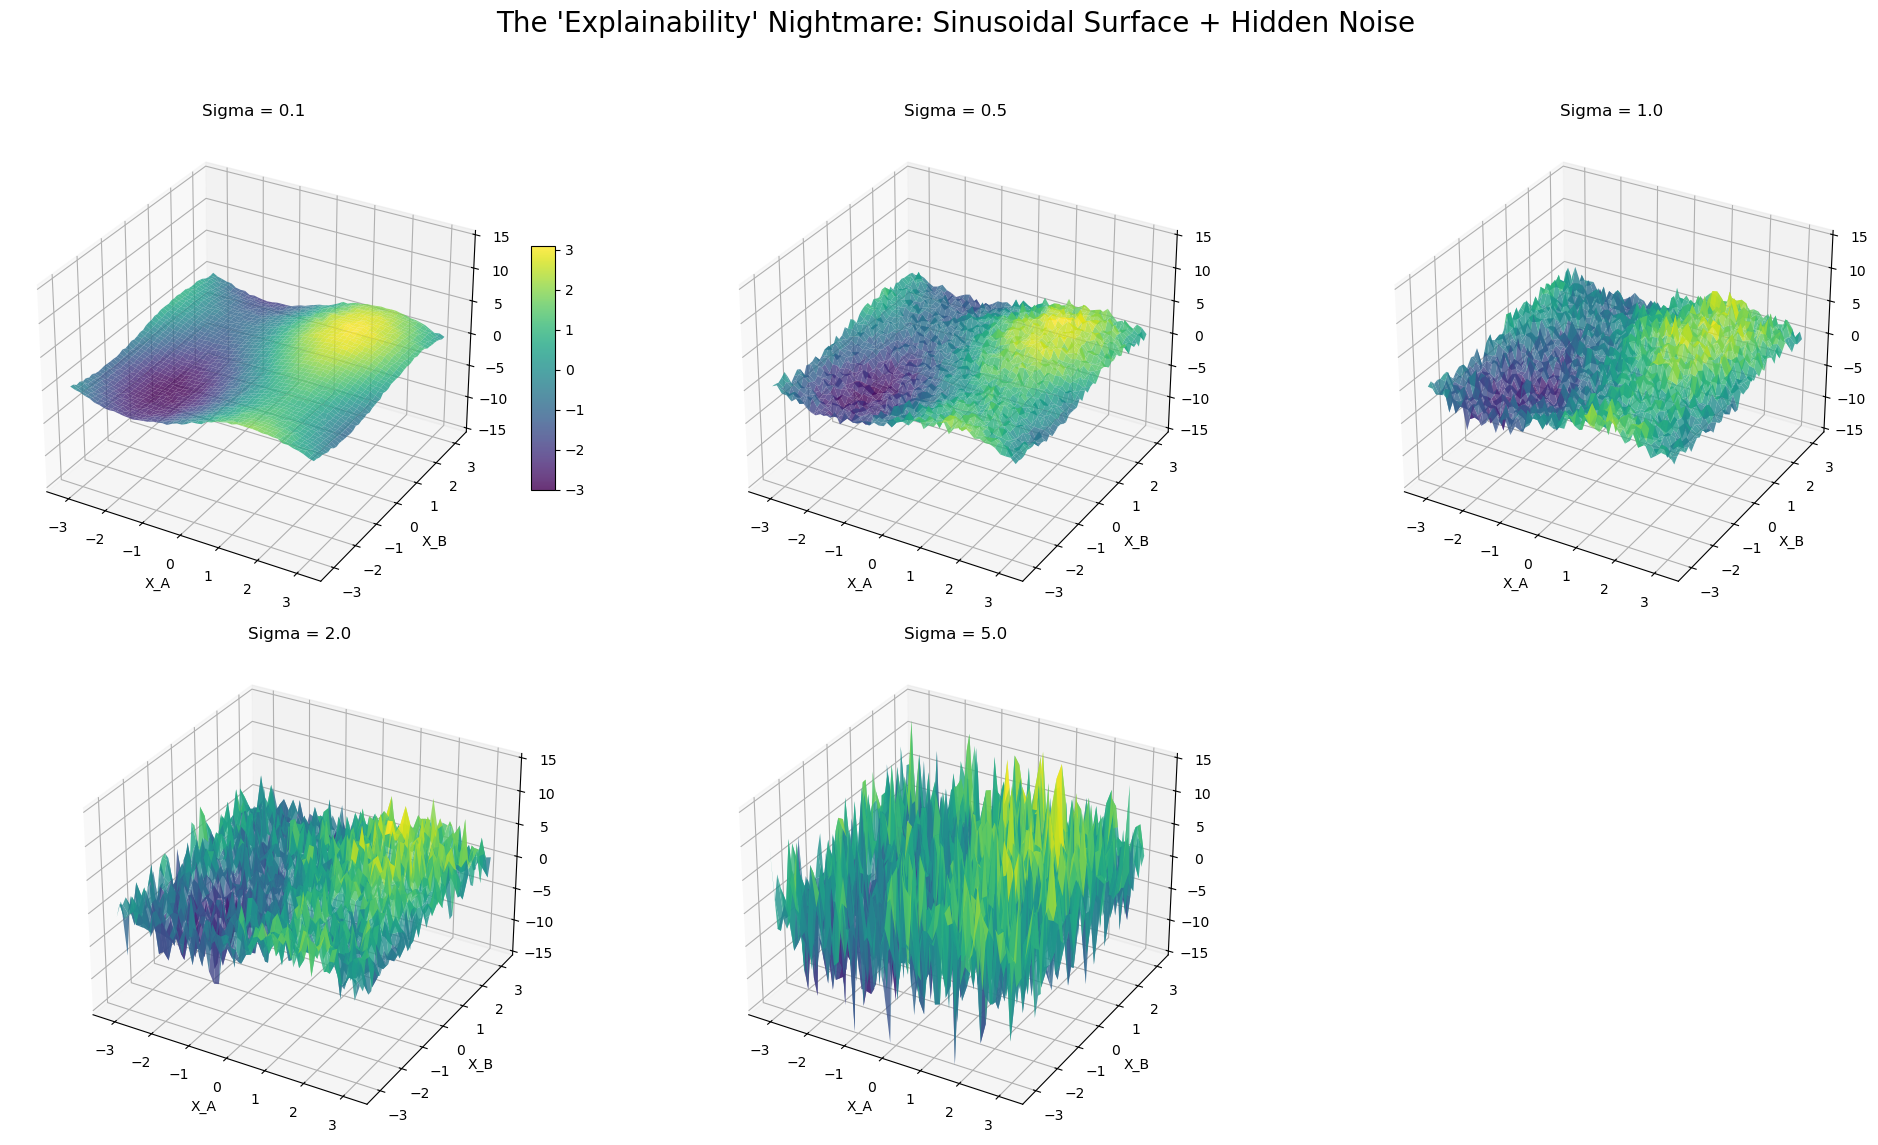

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_noisy_surfaces(sigmas):
    x = np.linspace(-np.pi, np.pi, 50)
    y = np.linspace(-np.pi, np.pi, 50)
    X, Y = np.meshgrid(x, y)
    
    w_a, w_b = 2.0, 1.0
    # True signal
    Z_true = w_a * np.sin(X) + w_b * np.sin(Y)
    
    fig = plt.figure(figsize=(20, 12))
    
    for i, s in enumerate(sigmas):
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        
        # Add noise
        noise = np.random.normal(0, s, Z_true.shape)
        Z_noisy = Z_true + noise
        
        # Surface plot
        surf = ax.plot_surface(X, Y, Z_noisy, cmap='viridis', edgecolor='none', alpha=0.8)
        
        ax.set_title(f"Sigma = {s}")
        ax.set_zlim(-15, 15) # Fixed Z-limit to show relative noise impact
        ax.set_xlabel('X_A')
        ax.set_ylabel('X_B')
        if i == 0:
            fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

    plt.suptitle("The 'Explainability' Nightmare: Sinusoidal Surface + Hidden Noise", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig('noisy_sine_subplots.png')
    print("Subplots saved as noisy_sine_subplots.png")

plot_noisy_surfaces([0.1, 0.5, 1.0, 2.0, 5.0])

Matrix plot saved as manifold_convergence_matrix.png


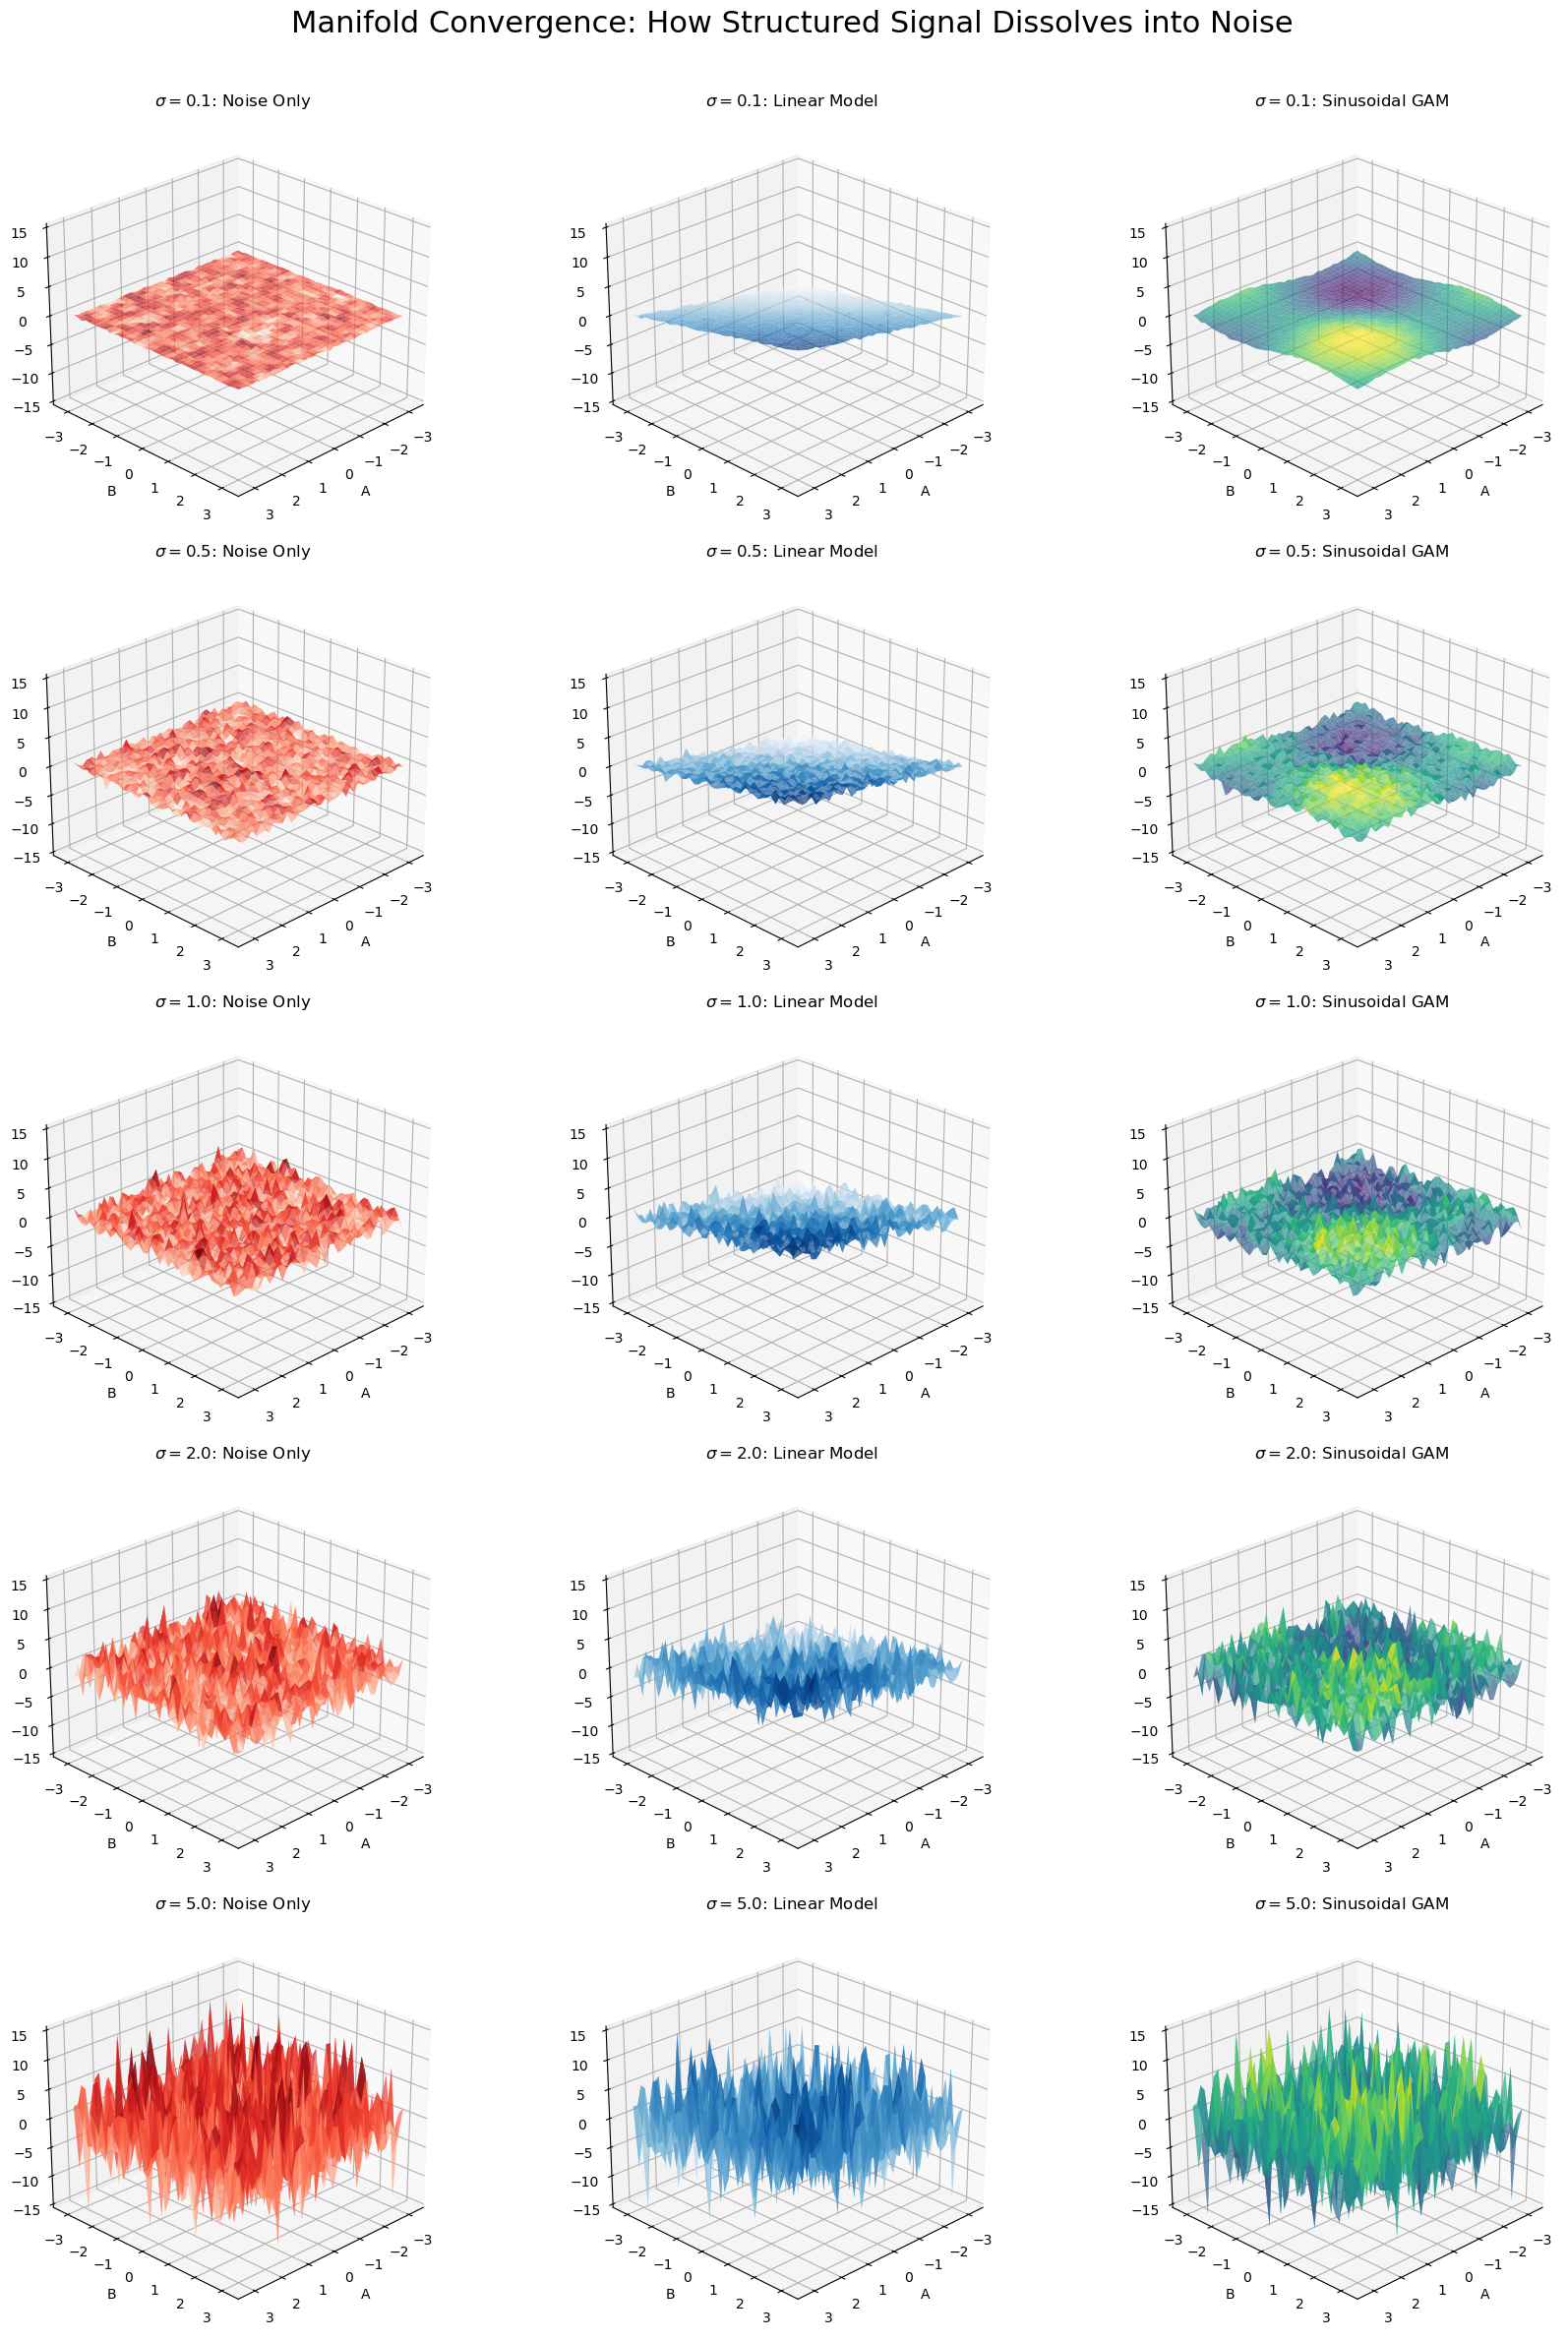

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_manifold_convergence(sigmas):
    # Reduced resolution for better performance and visualization
    x = np.linspace(-np.pi, np.pi, 40)
    y = np.linspace(-np.pi, np.pi, 40)
    A, B = np.meshgrid(x, y)
    
    fig = plt.figure(figsize=(18, 25))
    
    titles = ["Noise Only ($\epsilon$)", "Linear ($A + B + \epsilon$)", "Sinusoidal ($\sin(A) + \sin(B) + \epsilon$)"]
    
    for row, sigma in enumerate(sigmas):
        # Generate common noise for this row
        noise = np.random.normal(0, sigma, A.shape)
        
        # Col 1: Noise Only
        ax1 = fig.add_subplot(5, 3, row*3 + 1, projection='3d')
        ax1.plot_surface(A, B, noise, cmap='Reds', alpha=0.7)
        ax1.set_title(f"$\sigma={sigma}$: Noise Only")
        ax1.set_zlim(-15, 15)
        
        # Col 2: Linear
        ax2 = fig.add_subplot(5, 3, row*3 + 2, projection='3d')
        linear_z = (A + B) + noise
        ax2.plot_surface(A, B, linear_z, cmap='Blues', alpha=0.7)
        ax2.set_title(f"$\sigma={sigma}$: Linear Model")
        ax2.set_zlim(-15, 15)
        
        # Col 3: Sinusoidal
        ax3 = fig.add_subplot(5, 3, row*3 + 3, projection='3d')
        sine_z = (np.sin(A) + np.sin(B)) + noise
        ax3.plot_surface(A, B, sine_z, cmap='viridis', alpha=0.7)
        ax3.set_title(f"$\sigma={sigma}$: Sinusoidal GAM")
        ax3.set_zlim(-15, 15)
        
        # Clean up labels for subplots
        for ax in [ax1, ax2, ax3]:
            ax.set_xlabel('A')
            ax.set_ylabel('B')
            ax.view_init(elev=25, azim=45)

    plt.suptitle("Manifold Convergence: How Structured Signal Dissolves into Noise", fontsize=22)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.savefig('manifold_convergence_matrix.png')
    return 'manifold_convergence_matrix.png'

sigmas = [0.1, 0.5, 1.0, 2.0, 5.0]
file_name = plot_manifold_convergence(sigmas)
print(f"Matrix plot saved as {file_name}")

## Curvature

Wavelength sweep saved as wavelength_sweep_fixed.png


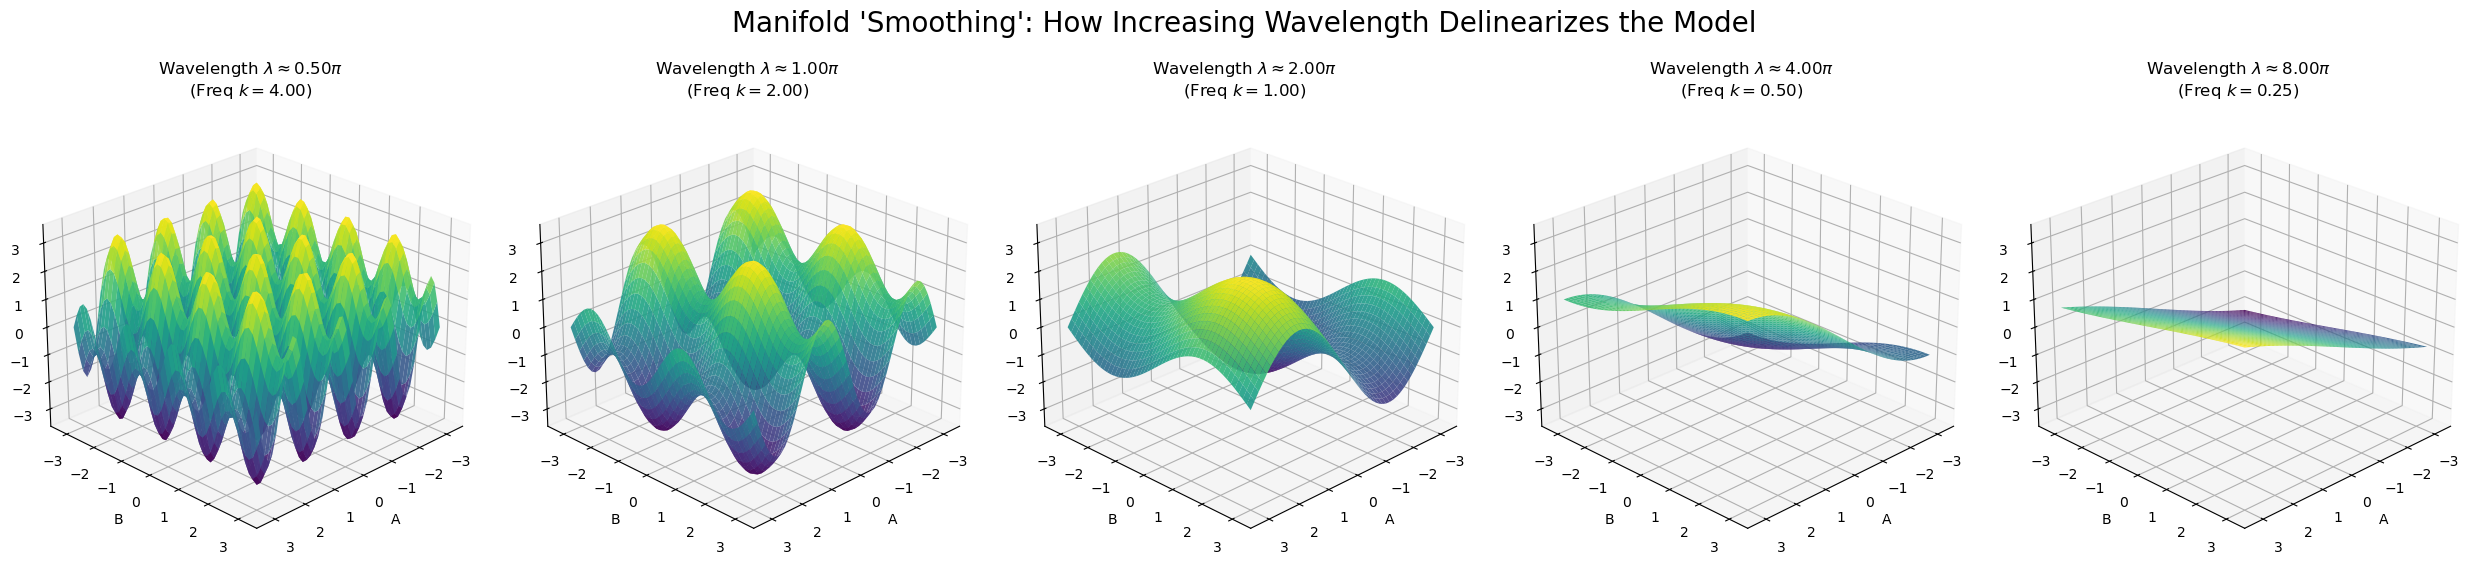

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_wavelength_sweep_corrected(wavelength_multipliers):
    x = np.linspace(-np.pi, np.pi, 50)
    y = np.linspace(-np.pi, np.pi, 50)
    A, B = np.meshgrid(x, y)
    
    # We'll use 2:1 weights to stay consistent with the experiment
    w_a, w_b = 2.0, 1.0
    
    fig = plt.figure(figsize=(25, 6))
    
    for i, lam_mult in enumerate(wavelength_multipliers):
        # Wavelength lambda = multiplier * pi
        # Frequency k = 2*pi / lambda = 2 / multiplier
        k = 2.0 / lam_mult
        
        Z = w_a * np.sin(k * A) + w_b * np.sin(k * B)
        
        ax = fig.add_subplot(1, 5, i+1, projection='3d')
        surf = ax.plot_surface(A, B, Z, cmap='viridis', edgecolor='none', alpha=0.9)
        
        # Use a raw-f-string to prevent \a (approx) being treated as a bell char
        title_str = fr"Wavelength $\lambda \approx {lam_mult:.2f}\pi$" + "\n" + fr"(Freq $k = {k:.2f}$)"
        ax.set_title(title_str)
        
        ax.set_zlim(-3.5, 3.5)
        ax.set_xlabel('A')
        ax.set_ylabel('B')
        ax.view_init(elev=25, azim=45)

    plt.suptitle("Manifold 'Smoothing': How Increasing Wavelength Delinearizes the Model", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.savefig('wavelength_sweep_fixed.png')
    return 'wavelength_sweep_fixed.png'

# multipliers for pi to set wavelength
multipliers = [0.5, 1.0, 2.0, 4.0, 8.0]
file_name = plot_wavelength_sweep_corrected(multipliers)
print(f"Wavelength sweep saved as {file_name}")

Using wavelength as control parameter on a GAM with sinusoidal transformation allows me to control linearity of the manifold, effectively making "delinearization" a tunable parameter. This is a more direct way to demonstrate how the shape of the underlying function affects the stability of explanations, without confounding it with noise magnitude.

This could be extended to combine delinearization and noise for more experiments.

I wonder what other tunable manifold properties there are...

Freq (k)   | Mean Curv  | SHAP A     | LIME A     | Ratio A/B
-----------------------------------------------------------------


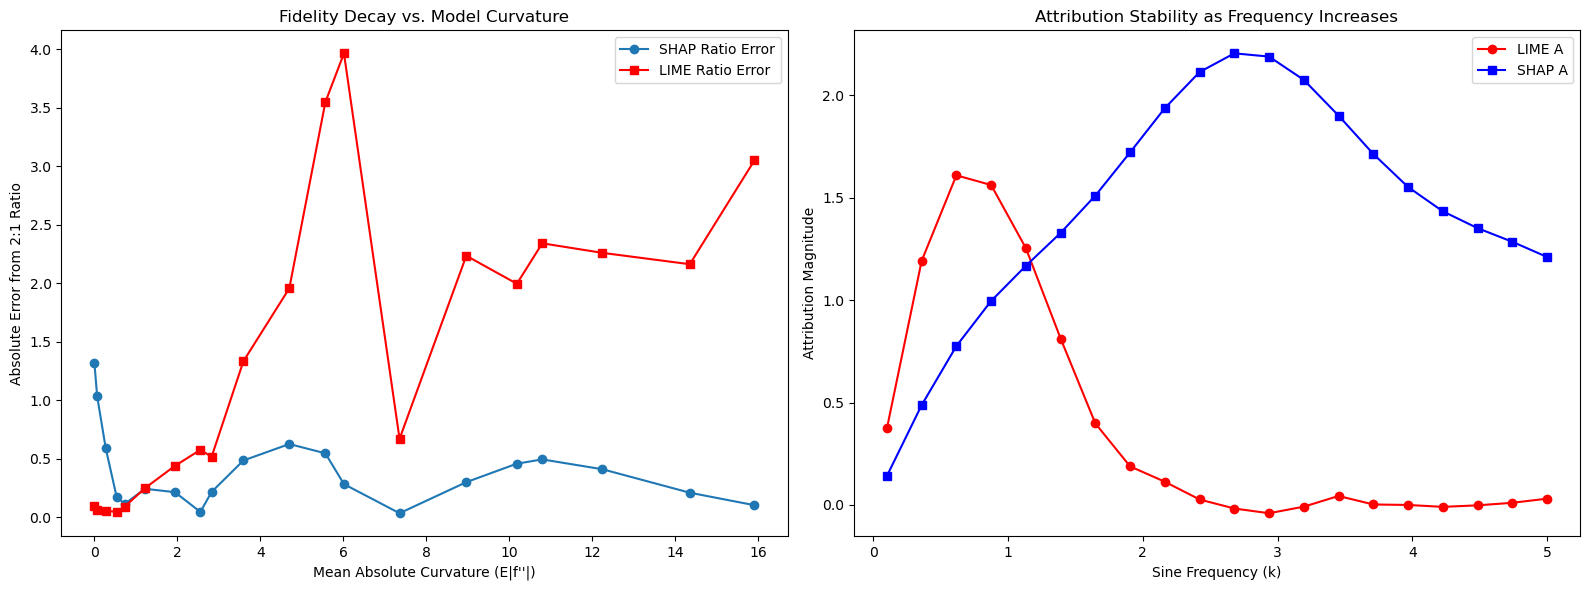

    Frequency  Curvature    SHAP_A    SHAP_B  SHAP_ratio    LIME_A    LIME_B  \
0    0.100000   0.001640  0.141729  0.042688    3.320145  0.373629  0.178031   
1    0.357895   0.067770  0.487384  0.160568    3.035366  1.191539  0.577736   
2    0.615789   0.274634  0.775801  0.299473    2.590558  1.609238  0.783388   
3    0.873684   0.539101  0.995905  0.458342    2.172844  1.561843  0.800560   
4    1.131579   0.732872  1.167518  0.619597    1.884318  1.253749  0.657171   
5    1.389474   1.221224  1.328122  0.756553    1.755491  0.812620  0.464397   
6    1.647368   1.941717  1.510159  0.846269    1.784491  0.398023  0.255228   
7    1.905263   2.554211  1.721128  0.881184    1.953199  0.188445  0.132424   
8    2.163158   2.826096  1.937128  0.873488    2.217692  0.113503  0.076617   
9    2.421053   3.591392  2.113157  0.849865    2.486462  0.026901  0.040422   
10   2.678947   4.697563  2.204604  0.839173    2.627113 -0.017154 -0.004334   
11   2.936842   5.566738  2.188669  0.85

In [13]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import warnings

warnings.filterwarnings("ignore")

def run_curvature_sweep():
    np.random.seed(42)
    n_samples = 200
    # Features range from -pi to pi to allow for full sine cycles
    X = np.random.uniform(-np.pi, np.pi, (n_samples, 2))
    feature_names = ['Signal_A', 'Signal_B']
    
    # We test at a "Slope" point (e.g., 0.5) where the ratio should be 2:1
    test_point = np.array([0.5, 0.5]) 
    
    # Sweep Frequency (k) from 0.1 (nearly linear) to 5.0 (highly oscillatory)
    frequencies = np.linspace(0.1, 5.0, 20)
    results = []

    lime_explainer = LimeTabularExplainer(
        X, mode="regression", feature_names=feature_names, discretize_continuous=False
    )

    print(f"{'Freq (k)':<10} | {'Mean Curv':<10} | {'SHAP A':<10} | {'LIME A':<10} | {'Ratio A/B'}")
    print("-" * 65)

    for k in frequencies:
        # Ground Truth Weights: A is 2x more important than B
        w_a, w_b = 2.0, 1.0
        
        def curvy_model(data):
            if data.ndim == 1: data = data.reshape(1, -1)
            # The Operationalization: Sine acts as the delinearization knob
            # Output = 2*sin(k*A) + 1*sin(k*B)
            return w_a * np.sin(k * data[:, 0]) + w_b * np.sin(k * data[:, 1])

        # --- Curvature Metric (Mean Absolute Second Derivative) ---
        # f(x) = sin(kx) -> f''(x) = -k^2 * sin(kx)
        # Average |f''| across the range for Signal A
        mean_curv = (k**2) * np.mean(np.abs(np.sin(k * X[:, 0])))

        # --- SHAP ---
        # SHAP integrates over the background, so it handles "wiggles" better
        shap_exp = shap.KernelExplainer(curvy_model, shap.sample(X, 50))
        shap_vals = shap_exp.shap_values(test_point.reshape(1, -1), nsamples=500, silent=True)[0]
        
        # --- LIME ---
        # LIME fits a linear plane to a "wiggly" neighborhood
        lime_exp = lime_explainer.explain_instance(test_point, curvy_model, num_features=2)
        lime_dict = {name: val for name, val in lime_exp.as_list()}

        results.append({
            'Frequency': k,
            'Curvature': mean_curv,
            'SHAP_A': shap_vals[0], 
            'SHAP_B': shap_vals[1],
            'SHAP_ratio': shap_vals[0]/shap_vals[1] if shap_vals[1] != 0 else np.inf,
            'LIME_A': lime_dict['Signal_A'], 
            'LIME_B': lime_dict['Signal_B'], 
            'LIME_ratio': lime_dict['Signal_A']/lime_dict['Signal_B'] if lime_dict['Signal_B'] != 0 else np.inf
        })
        

    df = pd.DataFrame(results)

    # --- Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Error vs Curvature
    ax[0].plot(df['Curvature'], np.abs(df['SHAP_ratio'] - 2.0), 'o-', label='SHAP Ratio Error')
    ax[0].plot(df['Curvature'], np.abs(df['LIME_ratio'] - 2.0), 's-', color='red', label='LIME Ratio Error')
    ax[0].set_title('Fidelity Decay vs. Model Curvature')
    ax[0].set_ylabel('Absolute Error from 2:1 Ratio')
    ax[0].set_xlabel('Mean Absolute Curvature (E|f\'\'|)')
    ax[0].legend()

    # Raw Attributions
    ax[1].plot(df['Frequency'], df['LIME_A'], 'o-', color='red', label='LIME A')
    ax[1].plot(df['Frequency'], df['SHAP_A'], 's-', color='blue', label='SHAP A')
    ax[1].set_title('Attribution Stability as Frequency Increases')
    ax[1].set_ylabel('Attribution Magnitude')
    ax[1].set_xlabel('Sine Frequency (k)')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    print(df)
    return df

if __name__ == "__main__":
    df_results = run_curvature_sweep()

It looks like SHAP is more stable than LIME as as wavelength increases and also approximatex attribution magnitude better.

## Interaction

Interaction matrix plot saved as interaction_sweep.png


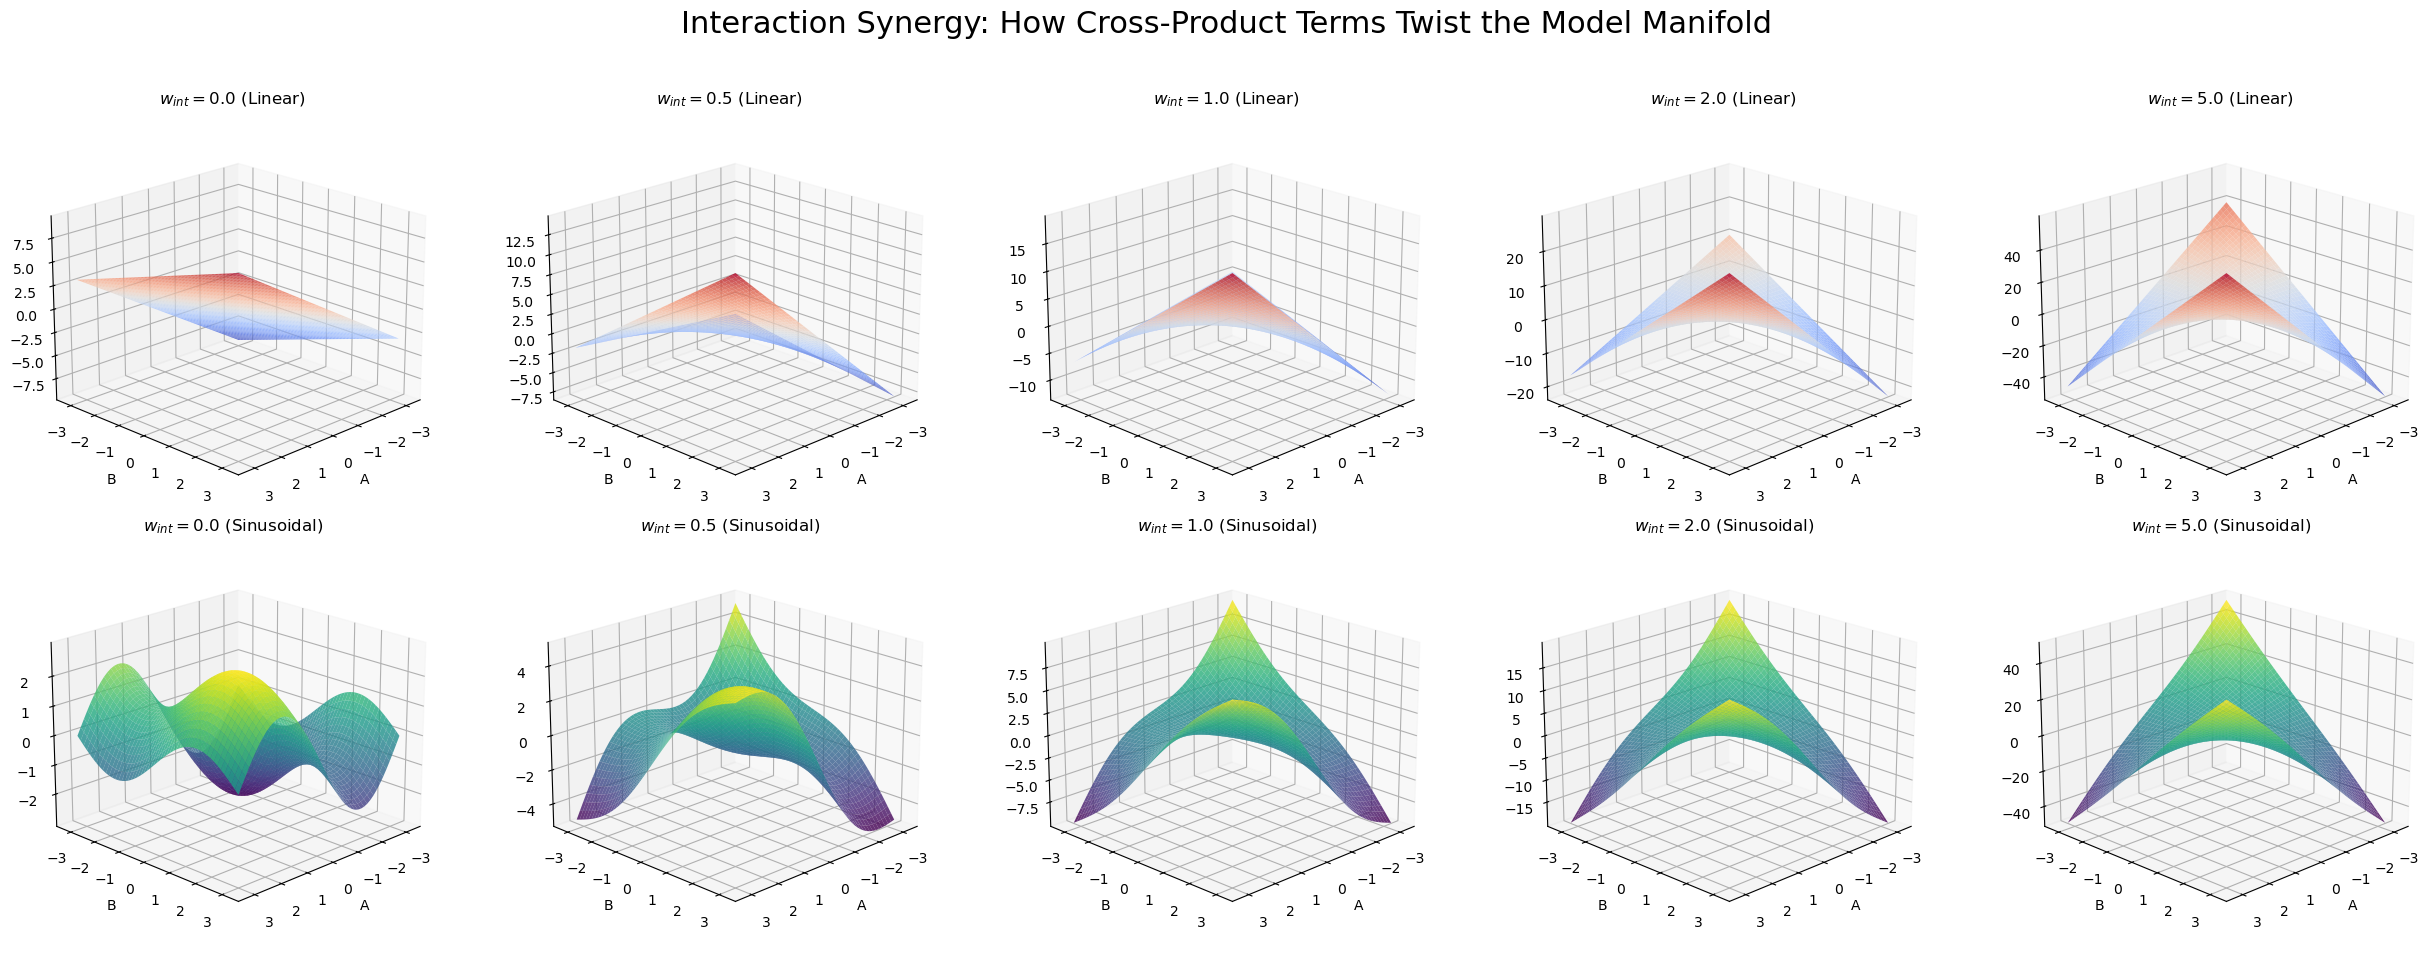

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_interaction_matrix(weights):
    x = np.linspace(-np.pi, np.pi, 50)
    y = np.linspace(-np.pi, np.pi, 50)
    A, B = np.meshgrid(x, y)
    
    # Base weights
    w_a, w_b = 2.0, 1.0
    
    num_cols = len(weights)
    fig = plt.figure(figsize=(25, 10))
    
    # Row 1: Linear + Interaction
    for i, w_int in enumerate(weights):
        Z = w_a * A + w_b * B + w_int * (A * B)
        ax = fig.add_subplot(2, num_cols, i + 1, projection='3d')
        ax.plot_surface(A, B, Z, cmap='coolwarm', alpha=0.8)
        ax.set_title(fr"$w_{{int}} = {w_int}$ (Linear)")
        ax.set_xlabel('A')
        ax.set_ylabel('B')
        ax.view_init(elev=20, azim=45)
        
    # Row 2: Sinusoidal + Interaction
    for i, w_int in enumerate(weights):
        Z = w_a * np.sin(A) + w_b * np.sin(B) + w_int * (A * B)
        ax = fig.add_subplot(2, num_cols, num_cols + i + 1, projection='3d')
        ax.plot_surface(A, B, Z, cmap='viridis', alpha=0.8)
        ax.set_title(fr"$w_{{int}} = {w_int}$ (Sinusoidal)")
        ax.set_xlabel('A')
        ax.set_ylabel('B')
        ax.view_init(elev=20, azim=45)

    plt.suptitle("Interaction Synergy: How Cross-Product Terms Twist the Model Manifold", fontsize=22)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('interaction_sweep.png')
    return 'interaction_sweep.png'

weights = [0.0, 0.5, 1.0, 2.0, 5.0]
file_name = plot_interaction_matrix(weights)
print(f"Interaction matrix plot saved as {file_name}")

W_int  | H-Stat | SHAP_A   | SHAP_B   | LIME_A   | LIME_B   | L_Ratio
--------------------------------------------------------------------------------
0.00   | 0.00   | 0.066    | -0.017   | 0.606    | 0.293    | 2.07
0.36   | 0.04   | 0.080    | -0.021   | 0.714    | 0.396    | 1.81
0.71   | 0.06   | 0.094    | -0.025   | 0.823    | 0.498    | 1.65
1.07   | 0.08   | 0.107    | -0.029   | 0.932    | 0.601    | 1.55
1.43   | 0.10   | 0.121    | -0.033   | 1.040    | 0.703    | 1.48
1.79   | 0.11   | 0.134    | -0.037   | 1.148    | 0.807    | 1.42
2.14   | 0.12   | 0.148    | -0.041   | 1.257    | 0.910    | 1.38
2.50   | 0.12   | 0.162    | -0.045   | 1.366    | 1.013    | 1.35
2.86   | 0.13   | 0.175    | -0.049   | 1.474    | 1.116    | 1.32
3.21   | 0.14   | 0.189    | -0.053   | 1.583    | 1.215    | 1.30
3.57   | 0.14   | 0.203    | -0.057   | 1.690    | 1.321    | 1.28
3.93   | 0.14   | 0.216    | -0.062   | 1.798    | 1.426    | 1.26
4.29   | 0.15   | 0.230    | -0.066   | 1.906

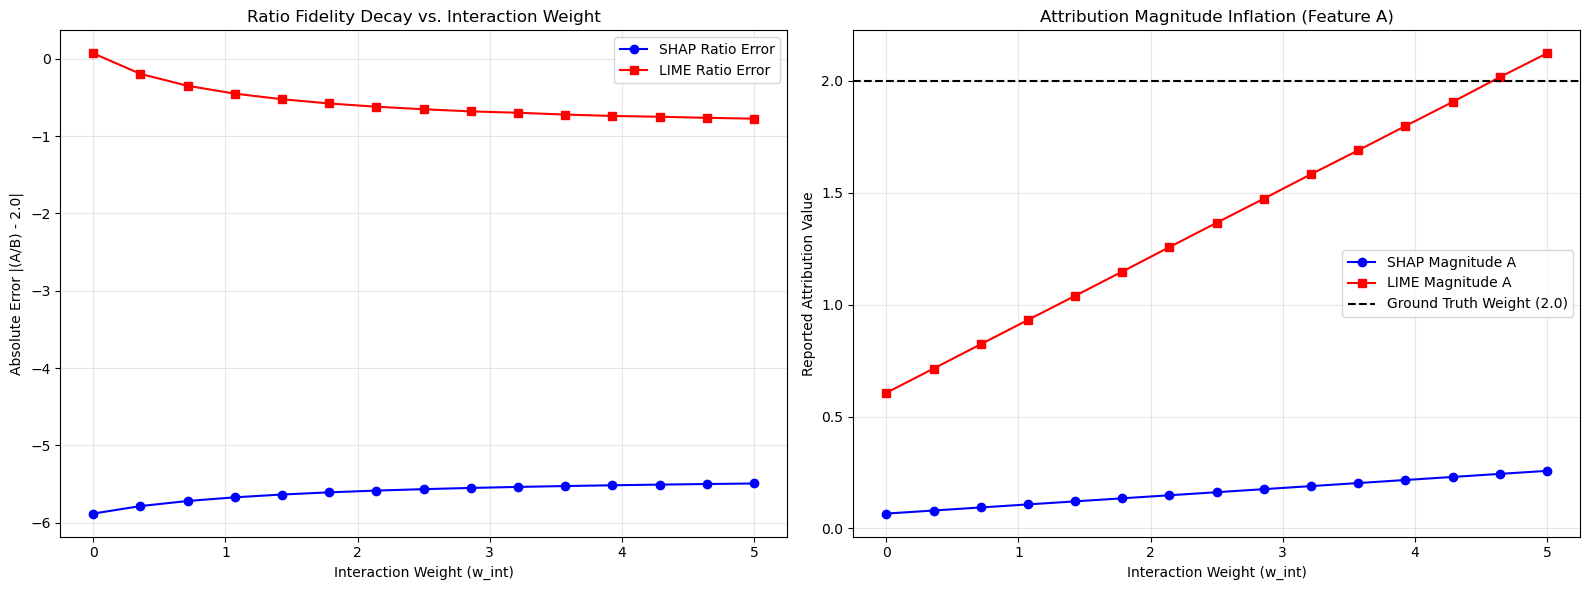

       W_int        H_Stat    SHAP_A    SHAP_B  SHAP_ratio    LIME_A  \
0   0.000000  4.405632e-16  0.066239 -0.017063   -3.882035  0.605987   
1   0.357143  3.751821e-02  0.079879 -0.021104   -3.785049  0.714422   
2   0.714286  6.339873e-02  0.093519 -0.025145   -3.719235  0.822997   
3   1.071429  8.223607e-02  0.107159 -0.029186   -3.671646  0.931729   
4   1.428571  9.652304e-02  0.120800 -0.033227   -3.635632  1.039549   
5   1.785714  1.077134e-01  0.134440 -0.037267   -3.607428  1.147817   
6   2.142857  1.167068e-01  0.148080 -0.041308   -3.584742  1.257250   
7   2.500000  1.240878e-01  0.161720 -0.045349   -3.566099  1.366179   
8   2.857143  1.302516e-01  0.175360 -0.049390   -3.550506  1.473816   
9   3.214286  1.354748e-01  0.189000 -0.053431   -3.537272  1.582983   
10  3.571429  1.399565e-01  0.202641 -0.057472   -3.525899  1.689827   
11  3.928571  1.438434e-01  0.216281 -0.061513   -3.516020  1.798411   
12  4.285714  1.472463e-01  0.229921 -0.065554   -3.507360  1.90

In [15]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import warnings

warnings.filterwarnings("ignore")

def calculate_h_stat(model, X):
    X_A = X.copy(); X_A[:, 1] = np.mean(X[:, 1])
    pd_a = model(X_A)
    X_B = X.copy(); X_B[:, 0] = np.mean(X[:, 0])
    pd_b = model(X_B)
    pd_joint = model(X)
    pd_a_c = pd_a - np.mean(pd_a); pd_b_c = pd_b - np.mean(pd_b); pd_j_c = pd_joint - np.mean(pd_joint)
    numer = np.sum((pd_j_c - (pd_a_c + pd_b_c))**2)
    denom = np.sum(pd_j_c**2)
    return np.sqrt(numer / denom) if denom > 0 else 0

def run_interaction_sweep():
    np.random.seed(42)
    n_samples = 300
    X = np.random.uniform(0.5, 1.5, (n_samples, 2))
    feature_names = ['Signal_A', 'Signal_B']
    test_points = np.random.uniform(0.9, 1.1, (10, 2)) 
    
    interaction_weights = np.linspace(0.0, 5.0, 15)
    results = []

    lime_explainer = LimeTabularExplainer(
        X, mode="regression", feature_names=feature_names, discretize_continuous=False
    )

    print(f"{'W_int':<6} | {'H-Stat':<6} | {'SHAP_A':<8} | {'SHAP_B':<8} | {'LIME_A':<8} | {'LIME_B':<8} | {'L_Ratio'}")
    print("-" * 80)

    for w_int in interaction_weights:
        w_a, w_b = 2.0, 1.0
        def interaction_model(data):
            if data.ndim == 1: data = data.reshape(1, -1)
            return w_a * data[:, 0] + w_b * data[:, 1] + w_int * (data[:, 0] * data[:, 1])

        h_val = calculate_h_stat(interaction_model, X)
        s_a, s_b, l_a, l_b = [], [], [], []
        
        for tp in test_points:
            shap_exp = shap.KernelExplainer(interaction_model, shap.sample(X, 50))
            s_vals = shap_exp.shap_values(tp.reshape(1, -1), nsamples=500, silent=True)[0]
            s_a.append(s_vals[0]); s_b.append(s_vals[1])
            
            l_exp = lime_explainer.explain_instance(tp, interaction_model, num_features=2)
            l_dict = {name: val for name, val in l_exp.as_list()}
            l_a.append(l_dict['Signal_A']); l_b.append(l_dict['Signal_B'])

        m_sa, m_sb = np.mean(s_a), np.mean(s_b)
        m_la, m_lb = np.mean(l_a), np.mean(l_b)

        results.append({
            'W_int': w_int,
            'H_Stat': h_val,
            'SHAP_A': m_sa,
            'SHAP_B': m_sb,
            'SHAP_ratio': m_sa / m_sb if m_sb != 0 else np.nan,
            'LIME_A': m_la,
            'LIME_B': m_lb,
            'LIME_ratio': m_la / m_lb if m_lb != 0 else np.nan
        })
        
        print(f"{w_int:<6.2f} | {h_val:<6.2f} | {m_sa:<8.3f} | {m_sb:<8.3f} | {m_la:<8.3f} | {m_lb:<8.3f} | {m_la/m_lb:.2f}")

    df = pd.DataFrame(results)
    
    # --- Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: Fidelity Decay (Error from 2.0)
    ax[0].plot(df['W_int'], df['SHAP_ratio'] - 2.0, 'o-', label='SHAP Ratio Error', color='blue')
    ax[0].plot(df['W_int'], df['LIME_ratio'] - 2.0, 's-', label='LIME Ratio Error', color='red')
    ax[0].set_title('Ratio Fidelity Decay vs. Interaction Weight')
    ax[0].set_xlabel('Interaction Weight (w_int)')
    ax[0].set_ylabel('Absolute Error |(A/B) - 2.0|')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Right: Magnitude Inflation of A
    ax[1].plot(df['W_int'], df['SHAP_A'], 'o-', label='SHAP Magnitude A', color='blue')
    ax[1].plot(df['W_int'], df['LIME_A'], 's-', label='LIME Magnitude A', color='red')
    ax[1].axhline(2.0, color='black', linestyle='--', label='Ground Truth Weight (2.0)')
    ax[1].set_title('Attribution Magnitude Inflation (Feature A)')
    ax[1].set_xlabel('Interaction Weight (w_int)')
    ax[1].set_ylabel('Reported Attribution Value')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(df)
    return df

if __name__ == "__main__":
    df_results = run_interaction_sweep()

Lime works in the beginning and then falls apart with limited decay as we increase interaction. SHAP fails from start and improves from there. Might be due to specific point and sample. Should test whether this persists for more samples.
As interaction increases LIME_A increases almost linearly, I wonder ift this would stop around 2, which is correct value or if LIME simply attributes interaction component to A and keeps increasing LIME_A linearly.

## Continuity

Discontinuity matrix plot saved as discontinuity_matrix.png


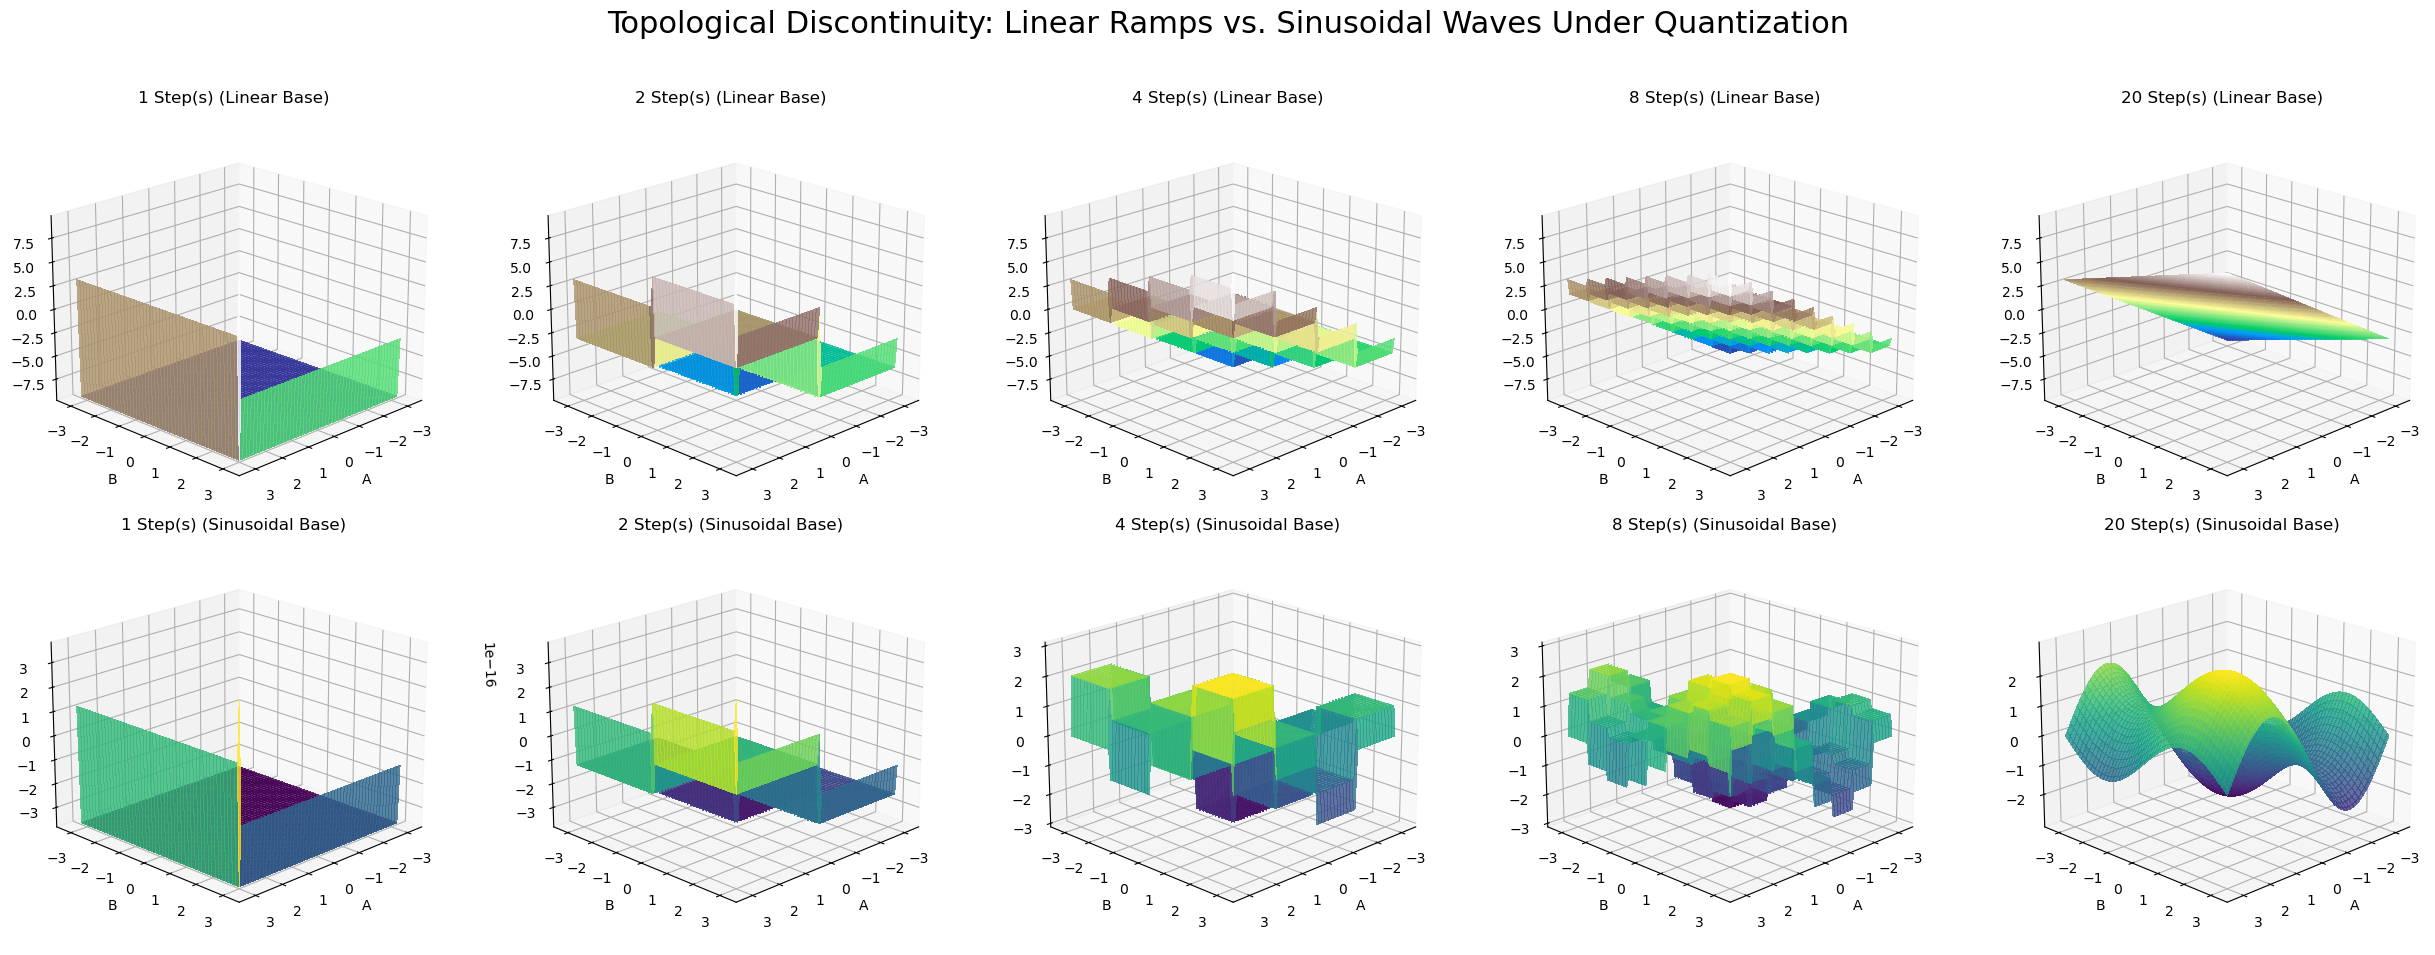

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_discontinuity_matrix(step_counts):
    x = np.linspace(-np.pi, np.pi, 100)
    y = np.linspace(-np.pi, np.pi, 100)
    A, B = np.meshgrid(x, y)
    
    # Base weights
    w_a, w_b = 2.0, 1.0
    
    num_cols = len(step_counts)
    fig = plt.figure(figsize=(25, 10))
    
    # Helper to quantize a signal
    def quantize(val, n):
        if n >= 20: return val # Convergence to continuous
        # Map range [-pi, pi] to [0, n] steps
        scaled = (val + np.pi) / (2 * np.pi)
        quantized = np.floor(scaled * n) / n
        return quantized * (2 * np.pi) - np.pi

    # Row 1: Linear + Discontinuity (Staircase)
    for i, n_steps in enumerate(step_counts):
        Za = w_a * quantize(A, n_steps)
        Zb = w_b * quantize(B, n_steps)
        Z = Za + Zb
        
        ax = fig.add_subplot(2, num_cols, i + 1, projection='3d')
        ax.plot_surface(A, B, Z, cmap='terrain', alpha=0.8, antialiased=False)
        ax.set_title(fr"{n_steps} Step(s) (Linear Base)")
        ax.set_xlabel('A')
        ax.set_ylabel('B')
        ax.view_init(elev=20, azim=45)
        
    # Row 2: Sinusoidal + Discontinuity (Pixelated Wave)
    for i, n_steps in enumerate(step_counts):
        Za = w_a * np.sin(quantize(A, n_steps))
        Zb = w_b * np.sin(quantize(B, n_steps))
        Z = Za + Zb
        
        ax = fig.add_subplot(2, num_cols, num_cols + i + 1, projection='3d')
        ax.plot_surface(A, B, Z, cmap='viridis', alpha=0.8, antialiased=False)
        ax.set_title(fr"{n_steps} Step(s) (Sinusoidal Base)")
        ax.set_xlabel('A')
        ax.set_ylabel('B')
        ax.view_init(elev=20, azim=45)

    plt.suptitle("Topological Discontinuity: Linear Ramps vs. Sinusoidal Waves Under Quantization", fontsize=22)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('discontinuity_matrix.png')
    return 'discontinuity_matrix.png'

steps = [1, 2, 4, 8, 20]
file_name = plot_discontinuity_matrix(steps)
print(f"Discontinuity matrix plot saved as {file_name}")

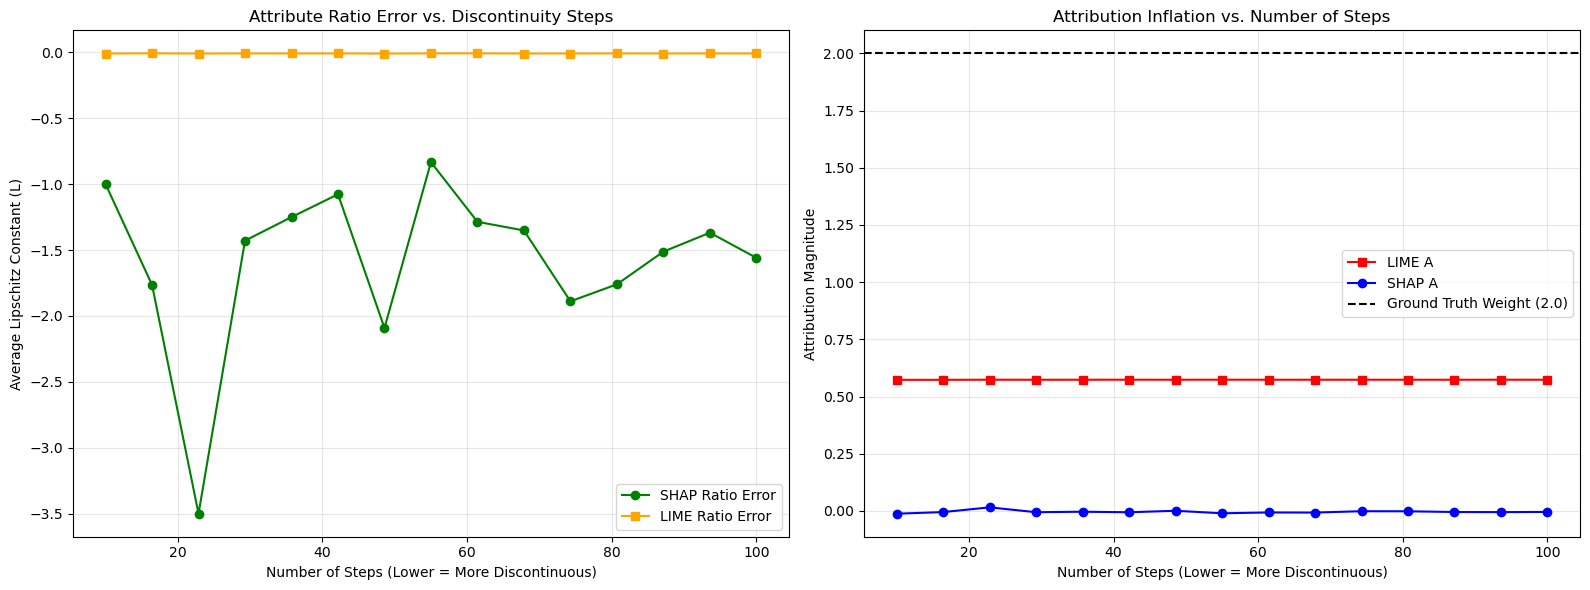

         Steps      Avg_L       Std_L    SHAP_A    SHAP_B  SHAP_ratio  \
0    10.000000  40.213552  100.512161 -0.012000 -0.012000    1.000000   
1    16.428571  22.345985   54.447038 -0.004870 -0.020696    0.235294   
2    22.857143  13.293295   18.480488  0.015750 -0.010500   -1.500000   
3    29.285714   9.248399    5.116470 -0.005463 -0.009561    0.571429   
4    35.714286  13.128902   12.534735 -0.003360 -0.004480    0.750000   
5    42.142857  21.089597   15.209542 -0.005695 -0.006169    0.923077   
6    48.571429  15.866661   17.286407  0.000824 -0.009059   -0.090909   
7    55.000000  11.171122    6.735302 -0.010182 -0.008727    1.166667   
8    61.428571  10.161548    4.848524 -0.006512 -0.009116    0.714286   
9    67.857143   8.992962    3.993102 -0.007074 -0.010905    0.648649   
10   74.285714  18.139209   18.657631 -0.001077 -0.009692    0.111111   
11   80.714286  10.298272    7.380536 -0.001487 -0.006195    0.240000   
12   87.142857   9.007168    4.891530 -0.004590 -0.

In [19]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
import warnings

warnings.filterwarnings("ignore")

def quantize(val, n):
    """
    Maps a continuous signal into n discrete steps across the range.
    High n = Smooth; Low n = Discontinuous Staircase.
    """
    if n >= 100: return val  # Effectively continuous
    # Assuming the data range is roughly [0.5, 1.5] for this simulation
    v_min, v_max = 0.5, 1.5
    scaled = (val - v_min) / (v_max - v_min)
    quantized = np.floor(scaled * n) / n
    return quantized * (v_max - v_min) + v_min

def estimate_local_lipschitz(model, point, epsilon=0.01, n_jitter=500):
    """Calculates the max local slope (L) to detect 'Step-ness'."""
    y_orig = model(point)
    noise = np.random.uniform(-epsilon, epsilon, (n_jitter, point.shape[0]))
    perturbed_points = point + noise
    y_perturbed = model(perturbed_points)
    
    distances = np.linalg.norm(noise, axis=1)
    distances = np.where(distances == 0, 1e-9, distances)
    diffs = np.abs(y_perturbed - y_orig.flatten())
    
    return np.max(diffs / distances)

def run_staircase_audit():
    np.random.seed(42)
    n_samples = 5000
    # Features A and B in range [0.5, 1.5]
    X = np.random.uniform(0.5, 1.5, (n_samples, 2))
    feature_names = ['Signal_A', 'Signal_B']
    
    # Test points specifically near a potential step edge
    test_points = np.random.uniform(0.95, 1.05, (10, 2))
    
    # Sweep from high-resolution (smooth) to low-resolution (jagged steps)
    step_counts = np.linspace(10, 100, 15)
    results = []

    lime_explainer = LimeTabularExplainer(
        X, mode="regression", feature_names=feature_names, discretize_continuous=False
    )


    for n in step_counts:
        w_a, w_b = 2.0, 1.0
        
        def staircase_model(data):
            if data.ndim == 1: data = data.reshape(1, -1)
            # Apply quantization to simulate tree-binning or cliffs
            A_q = quantize(data[:, 0], n)
            B_q = quantize(data[:, 1], n)
            return w_a * A_q + w_b * B_q

                # Storage for averaging across the manifold
        s_a, s_b, l_a, l_b, l_consts = [], [], [], [], []
        
        for tp in test_points:
            l_consts.append(estimate_local_lipschitz(staircase_model, tp))
            
            # SHAP
            shap_exp = shap.KernelExplainer(staircase_model, shap.sample(X, 50))
            s_vals = shap_exp.shap_values(tp.reshape(1, -1), nsamples=500, silent=True)[0]
            s_a.append(s_vals[0]); s_b.append(s_vals[1])
            
            # LIME
            l_exp = lime_explainer.explain_instance(tp, staircase_model, num_features=2)
            l_dict = {name: val for name, val in l_exp.as_list()}
            l_a.append(l_dict['Signal_A']); l_b.append(l_dict['Signal_B'])

        m_sa, m_sb = np.mean(s_a), np.mean(s_b)
        m_la, m_lb = np.mean(l_a), np.mean(l_b)
        m_L = np.mean(l_consts)
        sd_L = np.std(l_consts)

        results.append({
            'Steps': n,
            'Avg_L': m_L,
            'Std_L': sd_L,
            'SHAP_A': m_sa,
            'SHAP_B': m_sb,
            'SHAP_ratio': m_sa / m_sb if m_sb != 0 else np.nan,
            'LIME_A': m_la,
            'LIME_B': m_lb,
            'LIME_ratio': m_la / m_lb if m_lb != 0 else np.nan
        })
        

    df = pd.DataFrame(results)
    
    # --- Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: The Correlation between Interaction and Lipschitz Sensitivity
    ax[0].plot(df['Steps'], df['SHAP_ratio'] - 2.0, 'o-', color='green', label='SHAP Ratio Error')
    ax[0].plot(df['Steps'], df['LIME_ratio'] - 2.0, 's-', color='orange', label='LIME Ratio Error')
    ax[0].set_title('Attribute Ratio Error vs. Discontinuity Steps')
    ax[0].set_xlabel('Number of Steps (Lower = More Discontinuous)')
    ax[0].set_ylabel('Average Lipschitz Constant (L)')
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    # Right: Attribution Magnitude vs Lipschitz
    ax[1].plot(df['Steps'], df['LIME_A'], 's-', color='red', label='LIME A')
    ax[1].plot(df['Steps'], df['SHAP_A'], 'o-', color='blue', label='SHAP A')
    ax[1].axhline(2.0, color='black', linestyle='--', label='Ground Truth Weight (2.0)')
    ax[1].set_title('Attribution Inflation vs. Number of Steps')
    ax[1].set_xlabel('Number of Steps (Lower = More Discontinuous)')
    ax[1].set_ylabel('Attribution Magnitude')
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    print(df)
    return df

if __name__ == "__main__":
    df_results = run_staircase_audit()

LIME gets ratio right from start and is unaffected. SHAP has sign errors. Both underestimate attribution magnitude, but SHAP more so.